In [1]:
import numpy as np
import matplotlib as mlab
import matplotlib.pyplot as plt
import xarray as xr
import os as os
import matplotlib.gridspec as gridspec

#import cftime 
#from datetime import datetime as py_datetime

import datetime as dt

import scipy
import pandas as pd
import colormaps as cmaps

import glob

import sys

sys.path.append('/work/jessica.mcdonald/CAM_analysis_tools/filter/')
import RaymondFilters
#from RaymondFilters import RaymondFilter, inverseRaymondResponse, RaymondFilter6F
#import raymond_lowpass

import colormaps as cmaps

def findnearest(array, value):
    array = np.asarray(array)
    return (np.abs(array-value)).argmin()

## settings for plots - makes them look nicer
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.rc('xtick', labelsize=13) 
plt.rc('ytick', labelsize=13) 
plt.rc('axes', labelsize=14, titlesize=18) 
mpl.rcParams.update({"axes.grid" : False, "grid.color": "0.6",  'grid.linestyle':':',
                    'grid.linewidth':1, 'axes.labelweight':'bold', 'legend.framealpha':1.0})


import scipy
class HiddenPrints:
    def __enter__(self):
        self._original_stdout = sys.stdout
        sys.stdout = open(os.devnull, 'w')

    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stdout.close()
        sys.stdout = self._original_stdout


def force_eval(string):
    if type(string) == str:

        if '...' not in string:
            try:
                ret=np.array(eval(string.replace(' ', ',').replace('[,', '[').replace('\n', ',').replace(',,', ',')))
            except:
                ret =np.array(eval(string.replace('. ', '. ,').replace('\n', ',')))
            return ret
        else:
            print(' the ellipses bug happened...')
    else:
        print(f'TypeError: this function only processes a string and you gave type {type(string)}')

def get_obj_df(name, threshold, fpath, return_verification=True):
    all_mem = pd.read_csv(f'{fpath}/objects_{name}_{threshold}.csv')
    all_mem['time'] = pd.to_datetime(all_mem['time'])

    for i in all_mem.index:
        coords = force_eval(all_mem.loc[i, 'coords'])
        all_mem.loc[i, 'coords'] = [coords]
    
        coords = force_eval(all_mem.loc[i, 'coords_scaled'])
        all_mem.loc[i, 'coords_scaled'] = [coords]


    if return_verification:
        verif_obj = pd.read_csv(f'{fpath}/verification_{name}_{threshold}.csv')
        verif_obj['time'] = pd.to_datetime(verif_obj['time'])

        for i in verif_obj.index:
            coords = force_eval( verif_obj.loc[i, 'coords'])
            verif_obj.loc[i, 'coords'] = [coords]
        
            coords = force_eval( verif_obj.loc[i, 'coords_scaled'])
            verif_obj.loc[i, 'coords_scaled'] = [coords]

    
        return all_mem, verif_obj
    

# plots of filtered data with objects

In [5]:
exp = 'C3_5L09_R0'
fcst = ''

fpath=os.path.join('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/',exp, fcst)

#times = [dt.datetime.strptime(str(pd.to_datetime(t)),'%Y-%m-%d %H:%M:%S') for t in np.unique(all_mem.time)]
ds = xr.open_dataset('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/Processed_VerificationVars.nc')
ds = ds.rename({'UH2-5km':"UH_2-5km"})
times_NR = [dt.datetime.strptime(str(pd.to_datetime(t)),'%Y-%m-%d %H:%M:%S') for t in ds.dates.values]
ds.close()

xh, yh = np.meshgrid(ds.xh.values, ds.yh.values)

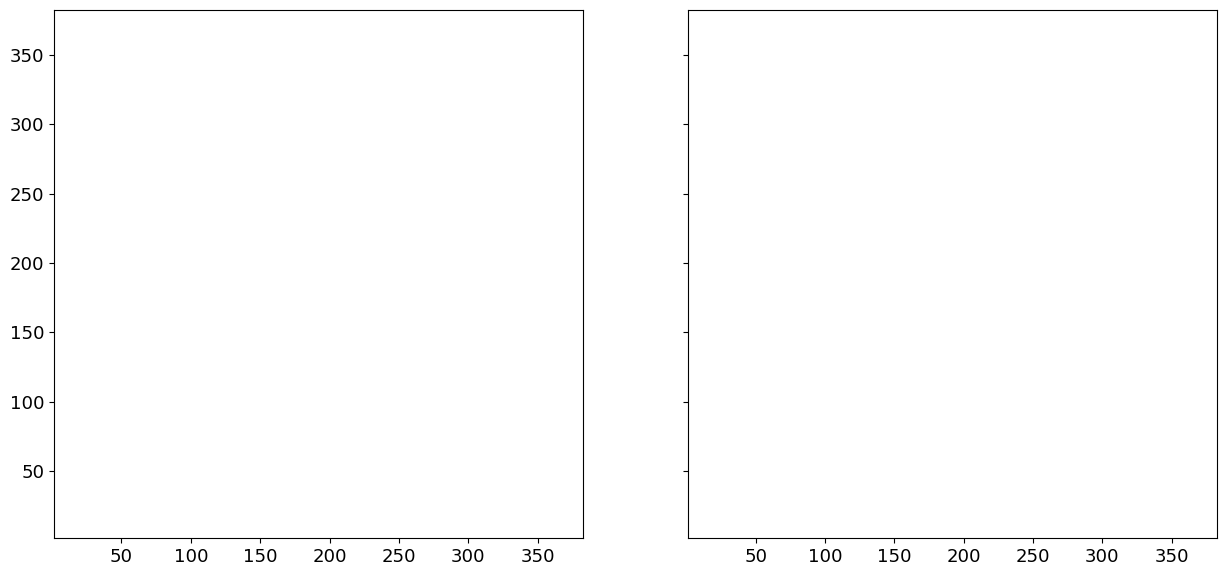

In [8]:
fig, axes =plt.subplots(1,2,figsize=(15,13), sharex=True, sharey=True, subplot_kw={'aspect':'equal'})


t=10




xh, yh = np.meshgrid(ds.xh, ds.yh)


################# reflectivity objects


var =  'cdbz'
name = 'compdbz'
ens_threshold = 40

all_mem = pd.read_csv(f'{fpath}/objects_{name}_{ens_threshold}.csv')
verif_obj = pd.read_csv(f'{fpath}/verification_{name}_{ens_threshold}.csv')
all_mem['time'] = pd.to_datetime(all_mem['time'])
verif_obj['time'] = pd.to_datetime(verif_obj['time'])

vob = verif_obj[verif_obj.time == times_NR[t]]
mem = all_mem[all_mem.time == times_NR[t]]

#axes[0].contourf(xh, yh, ds['cdbz'].values[t],levels=np.arange(40, 80, 10), cmap='Greys', alpha=0.6, antialiased=True)

for ax in axes:
    ax.contour(xh, yh, ds['cdbz'].values[t],levels=[10, 20, 30, 40, 50, 60, 70], colors='k', linewidths=0.5, alpha=0.5)
    ax.contour(xh, yh, ds['th'][t,0].values - ds['th'][t,0,-1].mean(axis=0).values,levels=[-1], colors='b', linewidths=1, alpha=0.5)


colors = cmaps.pride(np.linspace(.2, .8, len(vob.index)))

for v,vi in enumerate(vob.index):
    mask = np.zeros_like(xh)*np.nan
    coords = force_eval(vob.coords[vi])
    for c in coords:
        mask[c[0],c[1]] = 1
    axes[0].pcolormesh(xh, yh, mask, alpha=0.5, cmap=mpl.colors.ListedColormap([colors[v]]))
    
for m in mem.index:

    if mem.loc[m]['closest'] == 0: 
        color='w'
        alpha=1
    else:
      
        color = colors[findnearest(vob.Object_ID, mem.loc[m]['closest'])]
        alpha=1
    axes[0].scatter(mem.loc[m].X0, mem.loc[m].Y0, color=color, alpha=alpha, s=40, ec='k')

# for v,vi in enumerate(vob.index):
#     axes[0].scatter(vob.loc[vi].X0, vob.loc[vi].Y0, color=colors[v], marker='s',edgecolor='w', linewidth=1.5, s=100, zorder=100)

# axes[0].set_xlim(170-20,320)
# axes[0].set_ylim(70,300)


################# UH objects
name = 'UH'
ens_threshold = 100

all_mem = pd.read_csv(f'{fpath}/objects_{name}_{ens_threshold}.csv')
verif_obj = pd.read_csv(f'{fpath}/verification_{name}_{ens_threshold}.csv')
all_mem['time'] = pd.to_datetime(all_mem['time'])
verif_obj['time'] = pd.to_datetime(verif_obj['time'])

vob = verif_obj[verif_obj.time == times_NR[t]]
mem = all_mem[all_mem.time == times_NR[t]]

colors = cmaps.pride(np.linspace(.2, .8, len(vob.index)))

#axes[1].contourf(xh, yh, ds['UH_2-5km'].values[t],levels=np.arange(50, 1000, 50), cmap='Greys_r', alpha=0.6, antialiased=True)
#axes[1].contour(xh, yh, ds['cdbz'].values[t],levels=[10, 20, 30, 40, 50, 60, 70], colors='k', linewidths=0.5, alpha=0.5)



for v,vi in enumerate(vob.index):
    mask = np.zeros_like(xh)*np.nan
    coords = force_eval(vob.coords[vi])
    for c in coords:
        mask[c[0],c[1]] = 1
    axes[1].pcolormesh(xh, yh, mask, alpha=0.7, cmap=mpl.colors.ListedColormap([colors[v]]))
    

# Verification Dataset

In [2]:
######################################
#
# Step 1 - make full resolution dataset
#
######################################
times=[]
dates=[]

start_time = dt.datetime(2024,5,8,19,40)

ts = np.arange(1,181,1)

for i,t in enumerate(ts):
    print(t, end=',')

    cm1 = xr.open_dataset(f'/scratch/home/jessica.mcdonald/NR_500m_may8/cm1out_{t:06d}.nc', decode_timedelta=True)
    times.append(int(cm1.time.values[0]/1e9/60))

    dates.append(start_time + dt.timedelta(minutes=i))

    if t == 1:
        print('Reading in proper variables and set up')
        z = cm1.zh.values
        ztop = findnearest(z, 5)
        zbot = findnearest(z, 2)
        dx = np.gradient(cm1.xh)*1000
        dy = np.gradient(cm1.yh)*1000
        dz = np.gradient(cm1.zh)[zbot:ztop+1]*1000
        nt =len(ts)
        ni =cm1.sizes['xh']
        nj =cm1.sizes['yh']
        nk =cm1.sizes['zh']
        nkf=cm1.sizes['zf']
        
        UH      = np.empty([nt, nj, ni])
        u       = np.empty([nt, nk, nj, ni])
        v       = np.empty([nt, nk, nj, ni])
        w       = np.empty([nt, nk, nj, ni])
        wa      = np.empty([nt, nkf,nj, ni])
        th      = np.empty([nt, nk, nj, ni])
        qv      = np.empty([nt, nk, nj, ni])
        dbz     = np.empty([nt, nk, nj, ni])
  
    w [i,:] =cm1['winterp'][0,:].values
    u [i,:] =cm1['uinterp'][0,:].values
    v [i,:] =cm1['vinterp'][0,:].values
    wa[i,:] =cm1['w'][0,:].values
        
    th [i,:]=cm1['th'][0,:].values
    qv [i,:]=cm1['qv'][0,:].values
    dbz[i,:]=cm1['dbz'][0,:].values
    
    
    ### calculate 2-5km UH
    dudy = np.gradient(cm1.uinterp.values, axis=1)/dy
    dvdx = np.gradient(cm1.vinterp.values, axis=2)/dx
    zeta = dvdx-dudy
    UH[i, :] = np.sum(zeta[0,zbot:ztop+1]*cm1.winterp[0, zbot:ztop+1].values*dz[ :, np.newaxis, np.newaxis], axis=0)
    
    cm1.close

print('loading into a dataframe and saving')
coords = {'t'    : np.arange(0, nt),
          'ni'   : np.arange(0, ni),
          'nj'   : np.arange(0, nj),
          'nk'   : np.arange(0, nk),
          'nkp1' : np.arange(0, nkf)}

data_vars = { 'time'          : (['t'], times), 
              'dates'         : (['t'], dates), 
              'xh'            : (['ni'], cm1.xh.values), 
              'yh'            : (['nj'], cm1.yh.values),
              'zh'            : (['nk'], z),
              'zf'            : (['nkp1'], cm1.zf.values),
           
              'wa'            :(['t', 'nkp1','nj', 'ni'], wa),
              'w'             :(['t', 'nk','nj', 'ni'], w),
              'u'             :(['t', 'nk', 'nj', 'ni'], u),
              'v'             :(['t', 'nk', 'nj', 'ni'], v),
              'th'            :(['t', 'nk', 'nj', 'ni'], th),
              'qv'            :(['t', 'nk', 'nj', 'ni'], qv),
              'dbz'           :(['t', 'nk','nj', 'ni'], dbz),
              'UH2-5km'       :(['t', 'nj', 'ni'], UH)}        

myds = xr.Dataset(data_vars, coords)

myds.to_netcdf('/scratch/home/jessica.mcdonald/NR_500m_may8/Full_Verification_variables.nc', format='NETCDF4')

1,Reading in proper variables and set up
2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,loading into a dataframe and saving


In [ ]:
exp = 'oldCI_10min' ### this is just for a few random vars, it doesn't matter what I pick


myds = xr.open_dataset('/scratch/home/jessica.mcdonald/NR_500m_may8/Full_Verification_variables.nc')
ens = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/full_ens_fcst.nc', decode_timedelta=False)


Rens = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/member001/cm1rst_000024.nc', decode_timedelta=True)

NRvars = ['th','qv','dbz','u','v','wa','w'] # skip ua and va for now... idk if i need them 'ua','va','w','u','v','wa',
xh, yh, = ens.xh.values*1000, ens.yh.values*1000



dx_NR = 500
dx_filter = 3000 # this is the scale that everything smaller than will be filtered out
dx = int(dx_filter/dx_NR)
response_amp = 0.02
npass=1

eps = RaymondFilters.inverseRaymondResponse(response_amp, dx, npass=npass)



coords = {'t'     : myds.t.values,
          'ni'    : ens.ni.values,
          'nj'    : ens.nj.values,
          # 'klevs' : myds.klevs.values,
          'nk'    : myds.nk.values,
          'nkp1'  : myds.nkp1.values}

data_vars = { 'time'          : (['t'], myds.time.values), 
              'dates'         : (['t'], myds.dates.values), 
              'xh'            : (['ni'], ens.xh.values), 
              'yh'            : (['nj'], ens.yh.values),
              'zh'            : (['nk'], myds.zh.values),
              'zf'            : (['nkp1'],myds.zf.values)}
              # 'zlevs'         : (['klevs'], myds.zlevs.values),
              # 'actual_zlevs'  : (['klevs'], [findnearest(ens.z.values, zi*1000) for zi in myds.zlevs.values])}

filtds = xr.Dataset(data_vars, coords)

### loop over the variables

for vi in NRvars:
    print(vi)

    var = myds[vi]

    filt=np.empty(np.shape(var))
    
    nt = myds.sizes['t']
    nk = np.shape(var)[1]

    # # loop over all time and heights and filter
    for t in range(nt):
        if np.mod(t, 10) == 0: print(t, end=',')
        for z in range(nk):
            with HiddenPrints():
                filt[t,z]=RaymondFilters.RaymondFilter6F(var[t,z].values.T, eps, npass=npass)

    # create empty variable and determine levels to interpolate to
    
    
    # # 5 verification levels
    # if nk == len(myds.klevs):
    #     NRzvar = myds.actual_zlevs.values*1000
    #     ENzvar = [ens.z[findnearest(ens.z, zi)]*1000 for zi in myds.zlevs.values]
    
    if nk == len(myds.nk):
        zvar = myds.zh.values*1000
  
        
    if nk == len(myds.nkp1):
        zvar = myds.zf.values*1000

    temp = np.empty([nt,len(zvar), len(yh), len(xh)])
    
    x,y,z = np.meshgrid( xh, yh, zvar)
    
    # 500 m data is all in km, ensemble data is in meters
    # NOTE - this is triliear rn, but when I rerun the nature run, this will be bilinear
    
    for ti in range(nt):
        if np.mod(ti, 10) == 0: print(ti, end=',')
    
    
        finterp = scipy.interpolate.RegularGridInterpolator((zvar, myds.yh.values*1000, myds.xh.values*1000), filt[ti], bounds_error=False) #give it the filtered 500 m data
        temp[ti] = np.transpose(finterp((z.flatten(),y.flatten(),x.flatten())).reshape((len(zvar), len(yh), len(xh)), order='F'), axes=[0,2,1])

    filtds[vi] = ((var.dims), temp)
    del filt

ztop = findnearest(ens.z.values, 5)
zbot = findnearest(ens.z.values, 2)

dx  = np.gradient(xh)
dy  = np.gradient(yh)
dz  = np.gradient(ens.z.values*1000)[zbot:ztop+1]

dudy = np.gradient(filtds['u'].values, axis=2)/dy
dvdx = np.gradient(filtds['v'].values, axis=3)/dx
zeta = dvdx-dudy

UH = np.sum(zeta[:,zbot:ztop+1]*filtds['w'].values[:,zbot:ztop+1]*dz[np.newaxis,:, np.newaxis, np.newaxis], axis=1)
filtds['UH2-5km'] = (('t', 'nj', 'ni'), UH)
    
    
filtds.to_netcdf('/scratch/home/jessica.mcdonald/NR_500m_may8/Processed_VerificationVars.nc', format='NETCDF4')

th
0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,qv
0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,dbz
0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,u
0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,v
0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,wa
0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,w
0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,

PermissionError: [Errno 13] Permission denied: '/scratch/home/jessica.mcdonald/NR_500m_may8/Processed_VerificationVars.nc'

# 1.5 km version

In [ ]:

# !!!! I USED THIS CODE FOR MY 1.5 KM EXPERIMENTS, DO NOT CHANGE DIRECTLY !!!!!!!!!!!!!

exp = 'C03_H09_V2_fine' ### this is just for a few random vars, it doesn't matter what I pick


myds = xr.open_dataset('/scratch/home/jessica.mcdonald/NatureRuns/extra_NR_500m_may8/Full_Verification_variables.nc')
ens = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/full_ens_fcst.nc', decode_timedelta=False)
Rens = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/member001/cm1rst_000024.nc', decode_timedelta=True)

NRvars = ['th','qv','dbz','u','v','wa','w'] # skip ua and va for now... idk if i need them 'ua','va','w','u','v','wa',
xh, yh, = ens.xh.values*1000, ens.yh.values*1000



dx_NR = 500
dx_filter = 1500 # this is the scale that everything smaller than will be filtered out
dx = int(dx_filter/dx_NR)
response_amp = .02
npass=1

eps = RaymondFilters.inverseRaymondResponse(response_amp, dx, npass=npass)



coords = {'t'     : myds.t.values,
          'ni'    : ens.ni.values,
          'nj'    : ens.nj.values,
          # 'klevs' : myds.klevs.values,
          'nk'    : myds.nk.values,
          'nkp1'  : myds.nkp1.values}

data_vars = { 'time'          : (['t'], myds.time.values), 
              'dates'         : (['t'], myds.dates.values), 
              'xh'            : (['ni'], ens.xh.values), 
              'yh'            : (['nj'], ens.yh.values),
              'zh'            : (['nk'], myds.zh.values),
              'zf'            : (['nkp1'],myds.zf.values)}
              # 'zlevs'         : (['klevs'], myds.zlevs.values),
              # 'actual_zlevs'  : (['klevs'], [findnearest(ens.z.values, zi*1000) for zi in myds.zlevs.values])}

filtds = xr.Dataset(data_vars, coords)

### loop over the variables


for vi in NRvars:
    print(vi)

    var = myds[vi]

    filt=np.empty(np.shape(var))
    
    nt = myds.sizes['t']
    nk = np.shape(var)[1]

    # # loop over all time and heights and filter
    for t in range(nt):
        if np.mod(t, 10) == 0: print(t, end=',')
        for z in range(nk):
            with HiddenPrints():
                filt[t,z]=RaymondFilters.RaymondFilter6F(var[t,z].values.T, eps, npass=npass)

    # create empty variable and determine levels to interpolate to
    

    if nk == len(myds.nk):
        zvar = myds.zh.values*1000
  
    if nk == len(myds.nkp1):
        zvar = myds.zf.values*1000

    temp = np.empty([nt,len(zvar), len(yh), len(xh)])
    
    x,y,z = np.meshgrid( xh, yh, zvar)
    
    # 500 m data is all in km, ensemble data is in meters
    # NOTE - this is triliear rn, but when I rerun the nature run, this will be bilinear
    
    for ti in range(nt) :
        if np.mod(ti, 10) == 0: print(ti, end=',')
    
    
        finterp = scipy.interpolate.RegularGridInterpolator((zvar, myds.yh.values*1000, myds.xh.values*1000), filt[ti], bounds_error=False) #give it the filtered 500 m data
        temp[ti] = np.transpose(finterp((z.flatten(),y.flatten(),x.flatten())).reshape((len(zvar), len(yh), len(xh)), order='F'), axes=[0,2,1])

    filtds[vi] = ((var.dims), temp)
    del filt

ztop = findnearest(ens.z.values, 5)
zbot = findnearest(ens.z.values, 2)

dx  = np.gradient(xh)
dy  = np.gradient(yh)
dz  = np.gradient(ens.z.values*1000)[zbot:ztop+1]

dudy = np.gradient(filtds['u'].values, axis=2)/dy
dvdx = np.gradient(filtds['v'].values, axis=3)/dx
zeta = dvdx-dudy

UH = np.sum(zeta[:,zbot:ztop+1]*filtds['w'].values[:,zbot:ztop+1]*dz[np.newaxis,:, np.newaxis, np.newaxis], axis=1)
filtds['UH_2-5km'] = (('t', 'nj', 'ni'), UH)


filtds['cdbz'] = (('t', 'nj', 'ni'), filtds['dbz'].max(axis=1).values)

    
filtds.to_netcdf('/scratch/home/jessica.mcdonald/NatureRuns/extra_NR_500m_may8/Processed_VerificationVars_fine.nc', format='NETCDF4')

th
0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,qv
0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,dbz
0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,u
0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,v
0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,wa
0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,w
0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,

In [2]:

# ! note to self: this worked and didn't throw any hdf errors... i should start using context managers more often

with xr.open_dataset('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/Processed_VerificationVars_fine.nc') as temp:
    cdbz = temp['dbz'].max(axis=1).values
    temp['cdbz'] = (('t', 'nj', 'ni'), cdbz)
    temp = temp.drop_vars(['th','qv','dbz','u','v','wa','w','UH2-5km'])
    new = temp.copy()
new.to_netcdf('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/Processed_VerificationVars_fine.nc', format='NETCDF4', mode='a')

In [5]:
with xr.open_dataset('/scratch/home/jessica.mcdonald/NatureRuns/extra_NR_500m_may8/Processed_VerificationVars_fine.nc') as temp:
    temp['cdbz'].values

In [ ]:
### claude's version that I don't like
from scipy.ndimage import map_coordinates

exp = 'C03_H09_V2_fine'

myds = xr.open_dataset('/scratch/home/jessica.mcdonald/NatureRuns/extra_NR_500m_may8/Full_Verification_variables.nc')
ens  = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/full_ens_fcst.nc', decode_timedelta=False)
Rens = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/member001/cm1rst_000024.nc', decode_timedelta=True)

NRvars = ['th', 'qv', 'dbz', 'u', 'v', 'wa', 'w']
xh, yh = ens.xh.values * 1000, ens.yh.values * 1000

dx_NR     = 500
dx_filter = 1500
dx_filt   = int(dx_filter / dx_NR)
response_amp = 0.02
npass = 1

eps = RaymondFilters.inverseRaymondResponse(response_amp, dx_filt, npass=npass)


# NRvars = ['th']
# nt = 10

coords_ds = {
    't'    : myds.t.values,
    'ni'   : ens.ni.values,
    'nj'   : ens.nj.values,
    'nk'   : myds.nk.values,
    'nkp1' : myds.nkp1.values}

data_vars = {
    'time'  : (['t'],    myds.time.values),
    'dates' : (['t'],    myds.dates.values),
    'xh'    : (['ni'],   ens.xh.values),
    'yh'    : (['nj'],   ens.yh.values),
    'zh'    : (['nk'],   myds.zh.values),
    'zf'    : (['nkp1'], myds.zf.values)}

filtds = xr.Dataset(data_vars, coords_ds)

# ── Pre-compute fractional source indices once (reused for every variable & time step) ──────────
# RaymondFilter6F is called with var[t,z].values.T, so filt[ti] has shape (nk, nx_src, ny_src)
# i.e. axis 1 = x (ni), axis 2 = y (nj).  map_coordinates coordinates must follow this order.

src_y  = myds.yh.values * 1000                          # shape (ny_src,)
src_x  = myds.xh.values * 1000                          # shape (nx_src,)
y_idx  = (yh - src_y[0]) / float(src_y[1] - src_y[0])  # fractional y indices, shape (ny_ens,)
x_idx  = (xh - src_x[0]) / float(src_x[1] - src_x[0])  # fractional x indices, shape (nx_ens,)

nt        = myds.sizes['t']
nk_full   = len(myds.nk)
nkp1_full = len(myds.nkp1)
ny_ens    = len(yh)
nx_ens    = len(xh)

def _build_interp_coords(nz):
    """
    Build a (3, nz*ny_ens*nx_ens) coordinate array for map_coordinates.
    Axis order matches filt[ti] layout: (nz, nx_src, ny_src) due to the .T in the filter call.
    coords[1] indexes the x-axis (axis 1 of filt), coords[2] indexes the y-axis (axis 2).
    The result reshapes directly to (nz, ny_ens, nx_ens).
    """
    k_g, j_g, i_g = np.meshgrid(np.arange(nz), y_idx, x_idx, indexing='ij')
    # k_g[k,j,i]=k, j_g[k,j,i]=y_idx[j], i_g[k,j,i]=x_idx[i]
    # filt axis 1 is x  → pass i_g;  filt axis 2 is y  → pass j_g
    return np.array([k_g.ravel(), i_g.ravel(), j_g.ravel()])

coords_nk   = _build_interp_coords(nk_full)
coords_nkp1 = _build_interp_coords(nkp1_full)


# ── Main loop ────────────────────────────────────────────────────────────────────────────────────
for vi in NRvars:
    print(vi)
    var  = myds[vi]
    filt = np.empty(np.shape(var))
    nk   = np.shape(var)[1]

    # Raymond filtering (unchanged from original)
    for t in range(nt):
    #for t in nt:
        if np.mod(t, 10) == 0: print(t, end=',')
        for z in range(nk):
            with HiddenPrints():
                filt[t, z] = RaymondFilters.RaymondFilter6F(var[t, z].values.T, eps, npass=npass)
    print()

    # Bilinear horizontal interpolation with pre-computed indices
    # map_coordinates avoids recreating an interpolation object each time step and
    # skips the unnecessary z-dimension lookup (vertical grids are identical).
    interp_coords = coords_nk if nk == nk_full else coords_nkp1
    temp = np.empty([nt, nk, ny_ens, nx_ens])

    for ti in range(nt):
    #for t in nt:
        if np.mod(ti, 10) == 0: print(ti, end=',')
        temp[ti] = map_coordinates(
            filt[ti], interp_coords, order=1, mode='nearest', prefilter=False
        ).reshape(nk, ny_ens, nx_ens)
    print()

    # filtds[vi] = (var.dims, temp)
    # del filt

# ── UH ───────────────────────────────────────────────────────────────────────────────────────────
ztop = findnearest(ens.z.values, 5)
zbot = findnearest(ens.z.values, 2)

dx  = np.gradient(xh)
dy  = np.gradient(yh)
dz  = np.gradient(ens.z.values * 1000)[zbot:ztop+1]

dudy = np.gradient(filtds['u'].values, axis=2) / dy
dvdx = np.gradient(filtds['v'].values, axis=3) / dx
zeta = dvdx - dudy

UH = np.sum(
    zeta[:, zbot:ztop+1] * filtds['w'].values[:, zbot:ztop+1]
    * dz[np.newaxis, :, np.newaxis, np.newaxis],
    axis=1)
filtds['UH2-5km'] = (('t', 'nj', 'ni'), UH)

filtds.to_netcdf(
    '/scratch/home/jessica.mcdonald/NatureRuns/extra_NR_500m_may8/Processed_VerificationVars_fine.nc',
    format='NETCDF4')


th
0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,
0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,
qv
0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,
0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,
dbz
0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,
0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,
u
0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,
0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,
v
0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,
0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,
wa
0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,
0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,
w
0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,
0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,


KeyError: "No variable named 'u'. Variables on the dataset include ['time', 'dates', 'xh', 'yh', 'zh', ..., 't', 'ni', 'nj', 'nk', 'nkp1']"

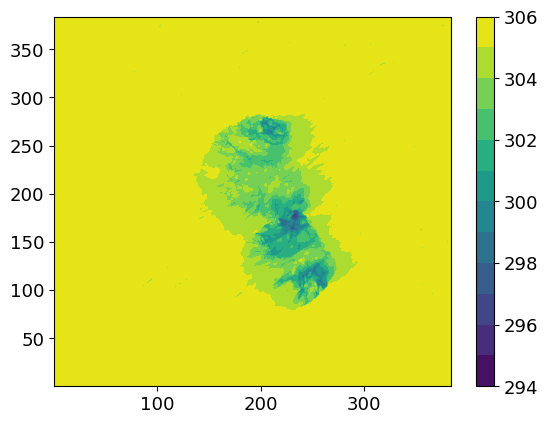

In [30]:
plt.contourf(myds.xh, myds.yh, filt[t, 0], levels=np.arange(294, 307,1))
plt.colorbar()

In [22]:
test = map_coordinates(
            filt[t], interp_coords, order=1, mode='nearest', prefilter=False
        ).reshape(nk, ny_ens, nx_ens)

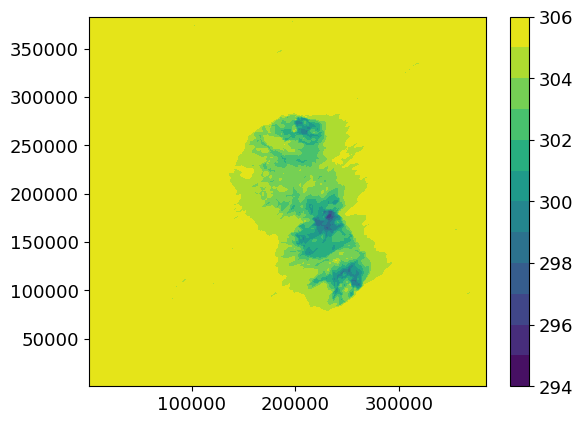

In [32]:
plt.contourf(xh,yh, test[0].T, levels=np.arange(294, 307,1))
plt.colorbar()

In [26]:
filtds.to_netcdf('/scratch/home/jessica.mcdonald/NatureRuns/extra_NR_500m_may8/Processed_VerificationVars_fine.nc', format='NETCDF4')

# tests

In [46]:
exp = 'C10_H18_V4' ### this is just for a few random vars, it doesn't matter what I pick


myds = xr.open_dataset('/scratch/home/jessica.mcdonald/extra_NR_500m_may8/Full_Verification_variables.nc')
ens = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/full_ens_fcst.nc', decode_timedelta=False)


Rens = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/member001/cm1rst_000024.nc', decode_timedelta=True)

NRvars = ['UH2-5km'] # skip ua and va for now... idk if i need them 'ua','va','w','u','v','wa',
xh, yh, = ens.xh.values*1000, ens.yh.values*1000


# dx_NR = 500
# dx_filter = 3000 # this is the scale that everything smaller than will be filtered out
# dx = int(dx_filter/dx_NR)
# response_amp = 0.1
# npass=1


dx_NR = 500
dx_filter = 3000 # this is the scale that everything smaller than will be filtered out
dx = int(dx_filter/dx_NR)
response_amp = 0.02
npass=1

eps = RaymondFilters.inverseRaymondResponse(response_amp, dx, npass=npass)



coords = {'t'     : myds.t.values,
          'ni'    : ens.ni.values,
          'nj'    : ens.nj.values,
          # 'klevs' : myds.klevs.values,
          'nk'    : myds.nk.values,
          'nkp1'  : myds.nkp1.values}

data_vars = { 'time'          : (['t'], myds.time.values), 
              'dates'         : (['t'], myds.dates.values), 
              'xh'            : (['ni'], ens.xh.values), 
              'yh'            : (['nj'], ens.yh.values),
              'zh'            : (['nk'], myds.zh.values),
              'zf'            : (['nkp1'],myds.zf.values)}
              # 'zlevs'         : (['klevs'], myds.zlevs.values),
              # 'actual_zlevs'  : (['klevs'], [findnearest(ens.z.values, zi*1000) for zi in myds.zlevs.values])}

filtds = xr.Dataset(data_vars, coords)

### loop over the variables

for vi in NRvars:
    print(vi)

    var = myds[vi]

    filt=np.empty(np.shape(var))
    
    nt = myds.sizes['t']

    # # loop over all time and heights and filter
    for t in range(nt):
        if np.mod(t, 10) == 0: 
            print(t, end=',')
        with HiddenPrints():
            filt[t]=RaymondFilters.RaymondFilter6F(var[t].values.T, eps, npass=npass)


#     temp = np.empty([nt, len(yh), len(xh)])
#     x,y = np.meshgrid( xh, yh)
    
#     # 500 m data is all in km, ensemble data is in meters
#     # NOTE - this is triliear rn, but when I rerun the nature run, this will be bilinear
    
#     for ti in range(nt):
#         if np.mod(ti, 10) == 0: print(ti, end=',')
    
#         finterp = scipy.interpolate.RegularGridInterpolator((myds.yh.values*1000, myds.xh.values*1000), filt[ti], bounds_error=False) #give it the filtered 500 m data
#         temp[ti] = np.transpose(finterp((y.flatten(),x.flatten())).reshape(( len(yh), len(xh)), order='F'))
    
#     filtds[vi] = ((var.dims), temp)
#     #del filt

    
    
# filtds.to_netcdf('/scratch/home/jessica.mcdonald/NR_500m_may8/Processed_UH_Test.nc', format='NETCDF4')

UH2-5km
0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,

In [47]:
temp = np.empty([nt, len(yh), len(xh)])
    
x,y = np.meshgrid( xh, yh)

# 500 m data is all in km, ensemble data is in meters
# NOTE - this is triliear rn, but when I rerun the nature run, this will be bilinear

for ti in range(nt):
    if np.mod(ti, 10) == 0: print(ti, end=',')

    finterp = scipy.interpolate.RegularGridInterpolator((myds.yh.values*1000, myds.xh.values*1000), filt[ti], bounds_error=False) #give it the filtered 500 m data
    temp[ti] = np.transpose(finterp((y.flatten(),x.flatten())).reshape(( len(yh), len(xh)), order='F'))

filtds[vi] = ((var.dims), temp)
del filt

    
    
filtds.to_netcdf('/scratch/home/jessica.mcdonald/extra_NR_500m_may8/Processed_UH_Test.nc', format='NETCDF4')

0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,

In [28]:
filtds

<xarray.Dataset> Size: 24MB
Dimensions:  (t: 180, ni: 128, nj: 128, nk: 52, nkp1: 53)
Coordinates:
  * t        (t) int64 1kB 0 1 2 3 4 5 6 7 8 ... 172 173 174 175 176 177 178 179
  * ni       (ni) int64 1kB 0 1 2 3 4 5 6 7 ... 120 121 122 123 124 125 126 127
  * nj       (nj) int64 1kB 0 1 2 3 4 5 6 7 ... 120 121 122 123 124 125 126 127
  * nk       (nk) int64 416B 0 1 2 3 4 5 6 7 8 9 ... 43 44 45 46 47 48 49 50 51
  * nkp1     (nkp1) int64 424B 0 1 2 3 4 5 6 7 8 ... 44 45 46 47 48 49 50 51 52
Data variables:
    time     (t) int64 1kB 0 1 2 3 4 5 6 7 8 ... 172 173 174 175 176 177 178 179
    dates    (t) datetime64[ns] 1kB 2024-05-08T19:40:00 ... 2024-05-08T22:39:00
    xh       (ni) float32 512B 1.5 4.5 7.5 10.5 13.5 ... 373.5 376.5 379.5 382.5
    yh       (nj) float32 512B 1.5 4.5 7.5 10.5 13.5 ... 373.5 376.5 379.5 382.5
    zh       (nk) float32 208B 0.1 0.3067 0.5267 0.76 ... 22.9 23.5 24.1 24.7
    zf       (nkp1) float32 212B 0.0 0.2 0.4133 0.64 ... 23.2 23.8 24.4 25.0
    UH2-5km  (t, nj, ni) float64 24MB 0.0 0.0 0.0 ... -0.8303 -0.7423 -0.7168

In [34]:
import colormaps as cmaps

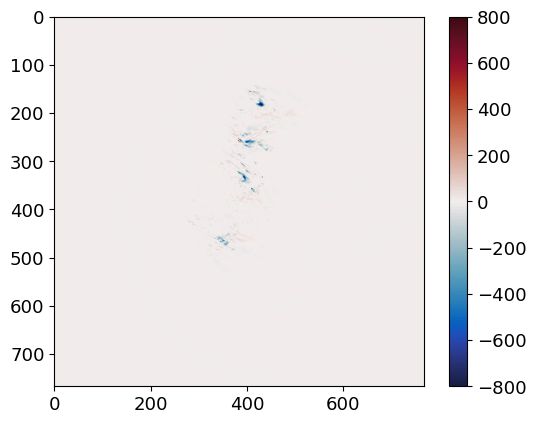

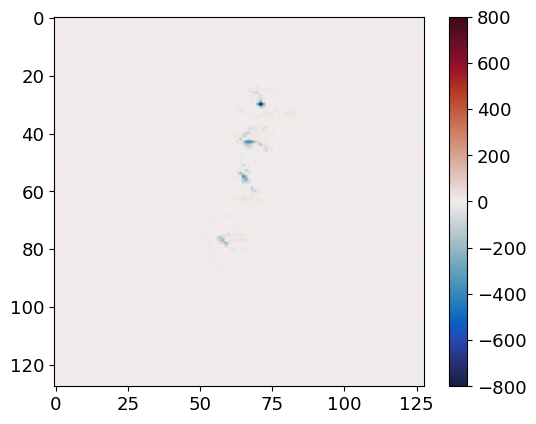

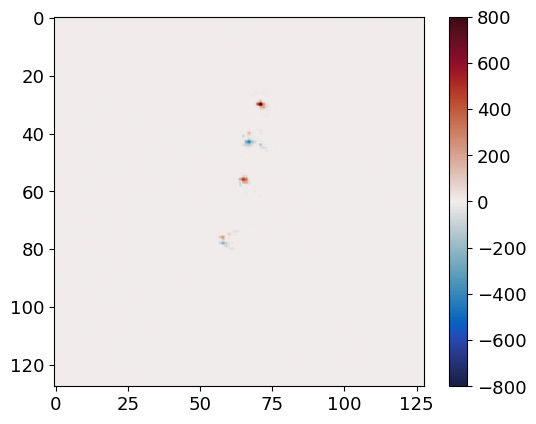

In [50]:
t = 120

plt.figure()
plt.imshow(var[t], vmin=-800, vmax=800, cmap=cmaps.balance)
plt.colorbar()



plt.figure()
plt.imshow(filtds['UH2-5km'][t], vmin=-800, vmax=800, cmap=cmaps.balance)
plt.colorbar()

plt.figure()
plt.imshow(fds['UH2-5km'][t], vmin=-800, vmax=800, cmap=cmaps.balance)
plt.colorbar()

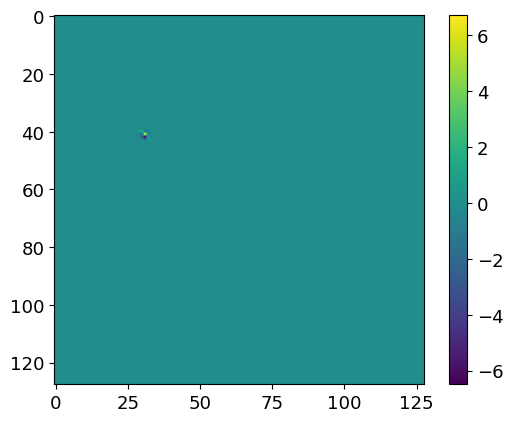

In [32]:
fds = xr.open_dataset('/scratch/home/jessica.mcdonald/extra_NR_500m_may8/Processed_VerificationVars.nc')


In [29]:
fds

<xarray.Dataset> Size: 9GB
Dimensions:  (t: 180, ni: 128, nj: 128, nk: 52, nkp1: 53)
Coordinates:
  * t        (t) int64 1kB 0 1 2 3 4 5 6 7 8 ... 172 173 174 175 176 177 178 179
  * ni       (ni) int64 1kB 0 1 2 3 4 5 6 7 ... 120 121 122 123 124 125 126 127
  * nj       (nj) int64 1kB 0 1 2 3 4 5 6 7 ... 120 121 122 123 124 125 126 127
  * nk       (nk) int64 416B 0 1 2 3 4 5 6 7 8 9 ... 43 44 45 46 47 48 49 50 51
  * nkp1     (nkp1) int64 424B 0 1 2 3 4 5 6 7 8 ... 44 45 46 47 48 49 50 51 52
Data variables: (12/15)
    time     (t) int64 1kB ...
    dates    (t) datetime64[ns] 1kB ...
    xh       (ni) float32 512B ...
    yh       (nj) float32 512B ...
    zh       (nk) float32 208B ...
    zf       (nkp1) float32 212B ...
    ...       ...
    u        (t, nk, nj, ni) float64 1GB ...
    v        (t, nk, nj, ni) float64 1GB ...
    wa       (t, nkp1, nj, ni) float64 1GB ...
    w        (t, nk, nj, ni) float64 1GB ...
    UH2-5km  (t, nj, ni) float64 24MB ...
    w_2-5km  (t, nj, ni) float64 24MB ...

# Distribution of variables

In [172]:
fds = xr.open_dataset('/scratch/home/jessica.mcdonald/NR_500m_may8/Processed_VerificationVars.nc')

def plot_distribution(ax, var, **kwargs):
    hist, bins = np.histogram(var, bins=100)
    bins = (bins[1:]+bins[:-1])/2.0
    ax.semilogy(bins, hist / len(var),**kwargs)

Text(0.5, 1.06, 'Filtered 3-km Nature Run Distributions')

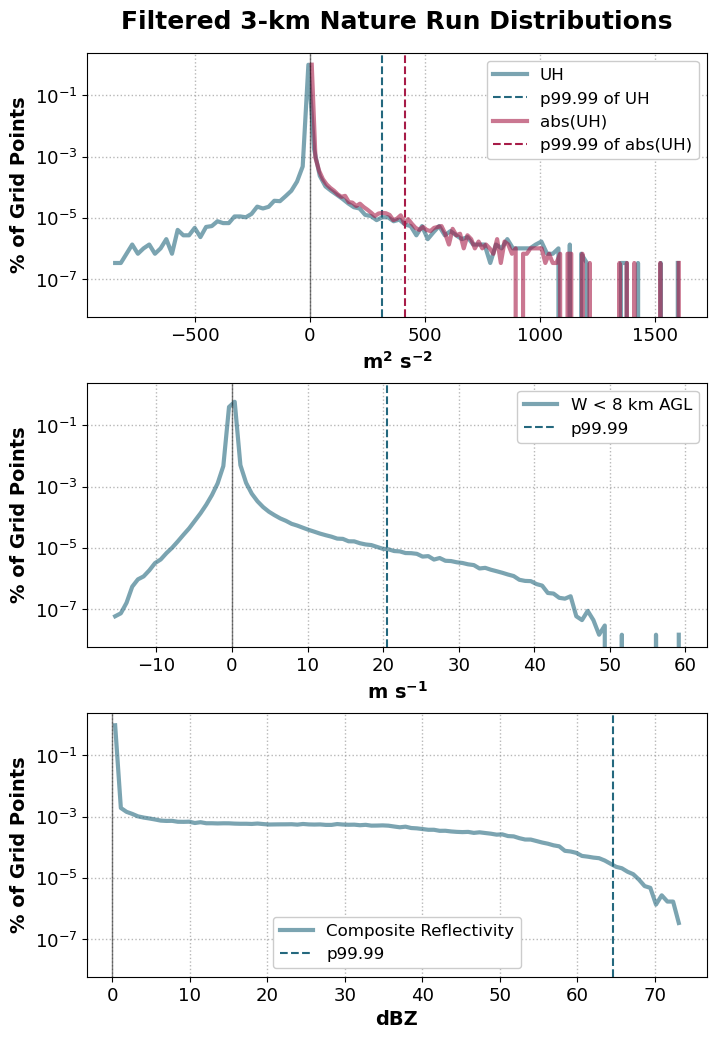

In [173]:

c = cmaps.lipari(np.linspace(.2, .75, 2))
c = cmaps.pride(np.linspace(.2, .8, 2))

var1 = (fds['UH2-5km'].values.flatten())
var2 = abs(fds['UH2-5km'].values.flatten())

w = fds['w'][:, :findnearest(fds.zh, 8)].values.flatten()
w = w[np.isnan(w)==False]

dbz = fds['dbz'][:, :].max(axis=1).values.flatten()

fig, axes=plt.subplots(3,1, figsize=(8,12), sharey=True)

## UH plot
for i,(var,label) in enumerate(zip([var1, var2], ['UH', 'abs(UH)'])):
    plot_distribution(axes[0], var, color=c[i], lw=3, alpha=0.6, label=label)
    axes[0].axvline(np.percentile(var, 99.99), ls='--',color=c[i], label=r'p99.99 of '+label)


## vertical velocity plot
plot_distribution(axes[1], w, color=c[0], lw=3, alpha=0.6, label='W < 8 km AGL')
axes[1].axvline(np.percentile(w, 99.99), ls='--',color=c[0], label=r'p99.99')  

## vertical velocity plot
plot_distribution(axes[2], dbz, color=c[0], lw=3, alpha=0.6, label='Composite Reflectivity')
axes[2].axvline(np.percentile(dbz, 99.99), ls='--',color=c[0], label=r'p99.99')

for ax in axes:
    ax.grid(ls=':', alpha=0.7)
    ax.axvline(0, color='k', lw=1, alpha=0.5)
    ax.set_ylabel('% of Grid Points')
    ax.legend(fontsize=12)
    
plt.subplots_adjust(hspace=0.25)

axes[0].set_xlabel(r'm$\mathbf{^2}$ s$\mathbf{^{-2}}$')
axes[1].set_xlabel(r'm s$\mathbf{^{-1}}$')
axes[2].set_xlabel(r'dBZ')

axes[0].set_title('Filtered 3-km Nature Run Distributions', y=1.06, weight='bold')

4.820120684634002
4.73141521459171


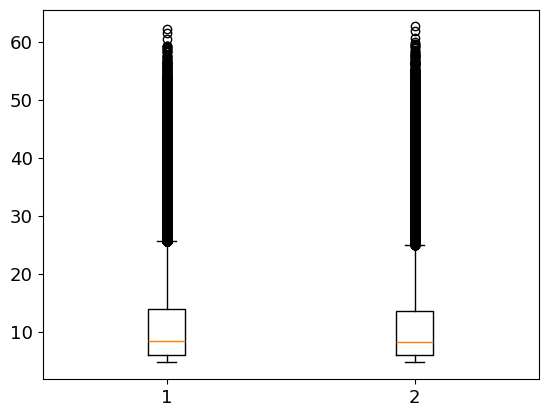

In [61]:
for i, vi in enumerate(['w', 'wa']):
    var = (fds[vi].values.flatten())
    #keep = var[var >=5]
    perc = np.nanpercentile(var, 99.9)
    keep = var[var >= perc]
    print(keep.min())

    plt.boxplot(keep, positions=[i+1]);

# Raymond Filter and Spectral Analysis Testing

In [2]:
import os, sys, argparse, cmath
import pylab as pl
import numpy as np
from scipy.fft import dct
from matplotlib import colors, ticker
import scipy.stats as stats
import matplotlib.pyplot as plt

_header = '-' * 100
_sep1   = ' ' * 10
_sep2   = ' ' * 20

_dct_type = 2
    
#-------------------------------------------------------------------------------------
def check_variance(array, spectra, dx=1.0, sep=_sep1):
    
    ny, nx = array.shape
    
    wnx = np.fft.fftshift(2 * np.pi * np.fft.fftfreq(nx, dx))
    wny = np.fft.fftshift(2 * np.pi * np.fft.fftfreq(ny, dx))
    
    dkx = wnx[1]-wnx[0]
    dky = wny[1]-wny[0]
    
    #########################################
    # Check that psd integrates to variance #
    #########################################
    # Built-in variance #
    #####################
    
    Raw_var= np.var(array)
    
    ########################
    # Built-in Integration #
    ########################
    
    DFT_var = integrate.trapz( integrate.trapz(spectra, dx=dky, axis=1), dx=dkx, axis=0)
    
    print("%s%sInput array variance         DFT Variance" % (sep, sep)  )
    print("%s%s-----------------------------------------" % (sep, sep))
    print("%s%s%15.10g            %15.10g\n" % (sep, sep, Raw_var, DFT_var) )
    
#-------------------------------------------------------------------------------------
def square_grid(fld, print_info):

    ny1, nx1 = fld.shape

    nny = int(ny1//2) 
    nnx = int(nx1//2)

    if print_info:
        print("Square Grid: 2D can only process same wavenumbers in X & Y, nx: %d  ny: %d\n" %(nx1,ny1))
        print("Square Grid: will sample a square domain using nx/2, ny/2 center point\n")

    if nx1 > ny1:
        tmp = fld[0:ny1,-nny+nnx:nnx+nny]
        nx1 = ny1
    if nx1 < ny1:
        tmp = fld[-nnx+nny:nny+nnx,0:nx1]
        ny1 = nx1
    else:
        tmp = fld.copy()
        
    if print_info:
        print("Square Grid:  New nx: %d  ny: %d\n" %(nx1,ny1))

    # now need to make the number of points even...

    mx = 2*(nx1//2)
    my = 2*(ny1//2)
    
    if print_info:
        print("Square Grid: New even nx: %d  even ny: %d\n" %(mx,my))

    return tmp[0:my,0:mx].copy()
#-------------------------------------------------------------------------------------

def remove_trend(fld, print_info):
    """
    Implementing Errico's (MWR 1985) 1D / 2D detrending algorithm
    
    """
    if len(fld.shape) == 1:
        
        ny = fld.shape
        
        sy = (fld[-1] - fld[0]) / (ny-1)
        
        scale = 0.5*(2*np.arange(1,ny+1) - ny - 1)
        
        fldy = fld - sy*scale
        
        return fldy
        
    elif len(fld.shape) == 2:
        
        ny, nx = fld.shape

        sy = (fld[-1,:] - fld[0,:]) / (ny-1)

        scale = 0.5*(2*np.arange(1,ny+1) - ny - 1)

        scale2d = np.broadcast_to(scale[:,np.newaxis], fld.shape)

        sy2d    = np.broadcast_to(   sy[np.newaxis,:], fld.shape)

        fldy = fld - scale2d*sy2d

        sx = (fldy[:,-1] - fldy[:,0]) / (nx-1)

        scale = 0.5*(2*np.arange(1,nx+1) - nx - 1)

        scale2d = np.broadcast_to(scale[np.newaxis,:], fld.shape)
        sx2d    = np.broadcast_to(   sx[:,np.newaxis], fld.shape)

        fldxy = fldy - scale2d*sx2d

        return fldxy
    
    else:
        print("Remove_trend:  Input array has invalid shape of:  %d, stopping code" % fld.shape)
        sys.exit(1)

#-------------------------------------------------------------------------------------
def get_spectra2D_DCT(fld, dx=1., dy=1., varray = None, sep=_sep1, **kwargs):
    """
    Code based on Nate Snook's implementation of the algorithm in Surcel et al. (2014)

    Arguments:
        `field` is a 2D numpy array for which you would like to find the spectrum
        `dx` and `dy` are the distances between grid points in the x and y directions in meters

    Returns a tuple of (length_scale, spectrum), where `length_scale` is the length scale in meters, and `spectrum` is 
        the power at each length scale.
    """


    # get some kwargs
    
    if 'print_info' in kwargs:
        print_info = kwargs['print_info']
    else:
        print_info = False
        
    if 'detrend' in kwargs:            # dont need to detrend data for DCT-II transform.
        detrend = kwargs['detrend']
    else:
        detrend = False
    
    u = square_grid(fld, print_info)
    
    if type(varray) != type(None):
        
        v = square_grid(varray, print_info)
            
    # compute spectra
    
    ny, nx = u.shape

    if type(varray) == type(None):
        
        variance = 0.5*dct(dct(u, axis=0, type=_dct_type, norm='ortho'), axis=1, type=_dct_type, norm='ortho')**2
        
    else:
        
        variance = 0.5*(dct(dct(u, axis=0, type=_dct_type, norm='ortho'), axis=1, type=_dct_type, norm='ortho')**2 \
                       +dct(dct(v, axis=0, type=_dct_type, norm='ortho'), axis=1, type=_dct_type, norm='ortho')**2)
           
    kfreq   = np.fft.fftfreq(nx) * nx
    kfreq2D = np.meshgrid(kfreq, kfreq)
    
    knrm   = np.sqrt(kfreq2D[0]**2 + kfreq2D[1]**2)
    knrm2  = 0.5*(knrm[1:,:] + knrm[:-1,:])
    knrm   = 0.5*(knrm2[:,1:] + knrm2[:,:-1])
    knrm   = knrm[:ny//2,:nx//2].flatten()
    
    # In order to make this similar to the DFT, you need to shift variances
    
    variance2 = np.zeros((ny,nx//2))
    variance3 = np.zeros((ny//2,nx//2))
    
    for i in np.arange(1,nx//2):   
        variance2[:,i-1] = variance[:,2*i-1] + variance[:,2*i]

    for j in np.arange(1,ny//2):   
        variance3[j-1,:] = variance2[2*j-1,:] + variance2[2*j,:]

    variance = variance3.flatten()
    
    kbins = np.arange(0.5, nx//2+1, 1.)
    kvals = 0.5 * (kbins[1:] + kbins[:-1])
    PSbins, _, _ = stats.binned_statistic(knrm, variance, statistic = "mean", bins = kbins)
    
    PSbins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)
    
    waven = 2.*kvals / nx
            
    return kvals, PSbins, waven

#-------------------------------------------------------------------------------------
# 2D Spectra

def get_spectra2D_RAD(fld, varray = None, sep=_sep1, **kwargs):
    """
    Returns 1D power spectra from a 2D field where 2D spectrum is averaged into radial bins.
    There are several caveats.  First, the shape of the fld array must be square.  If it is not square, 
    then it is made square by using the smallest dimension - one way or another the 2D spectrum can only 
    be represented by the dimensions along the smallest dimension (meaning the longer wavelengths
    are truncated).  The square is centered on [ny/2, nx/2] and has dimensions of (MIN(nx,ny))**2
    
    Second, the number of points must be an even number - which means dropping a single point at
    most, which we do at the end of the array.
    
    Update 08/18/22:  Decided to use the Durran paper method and compute the ampltitudes precisely
                      as they do - the amplitudes of spectrum are computed from the complex conjugates.
                      Also added in the ability, now that the raw arrays need to be passed, to do
                      2D KE by adding in a "varray" keyword argument.
    
    Input:  2D floating pont array
    
    Returns:  kvals:  mean wavenumber in each bin
              PSbins: power spectra which has been binned into kbins
              waven:  wavenumber (0 - 1) in non-dimensional space.
    """
    

    if 'print_info' in kwargs:
        print_info = kwargs['print_info']
    else:
        print_info = False
        
    if 'detrend' in kwargs:
        detrend = kwargs['detrend']
    else:
        detrend = False
        
    # print("%sget_spectra2D_RAD: computing spectra" % sep)  
    
    if detrend:
        u = remove_trend(square_grid(fld, print_info), print_info)
    else:
        u = square_grid(fld, print_info)

    ny, nx = u.shape
                
    if type(varray) != type(None):
        if detrend:
            v = remove_trend(square_grid(varray, print_info), print_info)
        else:
            v = square_grid(varray, print_info)
                   
    # assumes raw array are passed, computing using Durran's method
        
    uh = np.fft.fftn(u, norm='ortho')

    if type(varray) == type(None):

        fourier_amplitudes = 0.5*(uh * np.conj(uh)).real

    else:
        
        vh = np.fft.fftn(v, norm='ortho')
        fourier_amplitudes = 0.5*(uh * np.conj(uh) + vh * np.conj(vh)).real
            
    kfreq   = np.fft.fftfreq(nx) * nx
    kfreq2D = np.meshgrid(kfreq, kfreq)
    
    knrm    = np.sqrt(kfreq2D[0]**2 + kfreq2D[1]**2)
    knrm    = knrm.flatten()
    
    fourier_amplitudes = fourier_amplitudes.flatten()
    
    kbins = np.arange(0.5, nx//2+1, 1.)
    kvals = 0.5 * (kbins[1:] + kbins[:-1])
    
    PSbins, _, _ = stats.binned_statistic(knrm, fourier_amplitudes, statistic = "mean", bins = kbins)
    
    PSbins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)
    wavenumber = 2*(kvals-1)/nx
        
    return kvals, PSbins, wavenumber

#-------------------------------------------------------------------------------------
# 3D Spectra

def get_spectraND(fld, varray = None, func = get_spectra2D_RAD, sep = _sep1, **kwargs):
    """
    Returns average spectra from ND data set where the power spectra computed along
    the last two dimensions (often assumed to be x & y).  The input array can have
    3, 4, or even 5 dimensions (e.g., 5D => [case_day, fhours, klevels, ny, nx]
    and the function will reshape the input array to have 3 dimensions and then
    compute spectra over the last two dimensions using the 2D function passed
    and return the spectra from the last two dimensions.  Normally the spectra is averaged,
    over the first dimensions, but one can return the 3D array of spectra. 
    """
    
    if fld.ndim < 3:
        print("%s%s" % (sep, _header))
        print("%sget_spectraND: Array is wrong size, input array must have at least 3 dimensions\n" % (_sep1))
        return None
    
    if fld.ndim > 2:
        
        fshape = fld.shape
        start = 0
        count = fld.ndim-2

        fld3d = np.reshape(fld.copy(), fshape[:start] + (-1,) + fshape[start+count:])
                    
        if fld.ndim > 3:
            print("%s%s" % (_sep1, _header))
            print("%sget_spectraND: Reshaped array so that spectra averaged over outer dimension: %d\n" % (_sep1, fld3d.shape[0]))

        Abins = []
        
        print("%s%s" % (_sep2, _header))
        print("%s%s is now being called" % (_sep2, func.__name__))
        
        if type(varray) != type(None):
            
            fld3d_v = np.reshape(varray.copy(), fshape[:start] + (-1,) + fshape[start+count:])

            for k in np.arange(fld3d.shape[0]):
                kvals, A, waven = func(fld3d[k], varray = fld3d_v[k], sep = _sep2, **kwargs)
                Abins.append(A)
        else:
            
            for k in np.arange(fld3d.shape[0]):
                kvals, A, waven = func(fld3d[k], sep = _sep2, **kwargs)
                Abins.append(A)

        Abins = np.asarray(Abins)
        
        print("\n")
        
        return kvals, Abins.mean(axis=0), waven
#-------------------------------------------------------------------------------------
# Plot spectral
    
def plot_spectra(fld, varray = None, func = get_spectra2D_RAD, legend = None, ax = None, linecolor='k', label=None, linestyle='-', linewidth=1.5, 
                 ptitle='Power Spectra', loglog=1, LinsborgSlope = False, **kwargs):

    # for key, value in kwargs.items():
    #        print(f"{key} = {value}")
    
    import matplotlib.ticker as mticker
    # from spectra.py_spectra import get_spectra2D_RAD
    
    if 'print_info' in kwargs:
        print_info = kwargs['print_info']
    else:
        print_info = False
        
    if 'detrend' in kwargs:
        detrend = kwargs['detrend']
    else:
        detrend = False
        
# -------------

    print("%s" % _header)
    print("plot_spectra: Computing power spectrum using function: %s" % (func.__name__))
    
    if 'mean_power' in kwargs:
        print("plot_spectra: Requesting mean-power, not summed-power to be plotted")
        
    if type(varray) == type(None):
        print("plot_spectra: Spectrum from a single variable")
    else:
        print("plot_spectra: Spectrum computed for KE")
    print("plot_spectra: DETREND = %s\n" % (detrend))
    
# -------------

    # This next set of code does most of the work
        
    if len(fld.shape) < 3:  
                
        kvals, Abins, waven = func(fld, varray = varray, func=func, sep=_sep1, **kwargs)
        
    else:
                
        kvals, Abins, waven = get_spectraND(fld, varray = varray, func = func, sep=_sep2, **kwargs)

    if print_info:
        print('kvals:      ',kvals.shape, kvals)
        print('PS:         ',Abins.shape, Abins)
        print('wavenumber: ',waven.shape, waven)

    if ax == None:
        fig, axes = plt.subplots(1, 1, constrained_layout=True,figsize=(10,8))
        
    else:
        axes = ax
        
    if loglog:
        
        axes.loglog(waven, Abins, color=linecolor, linestyle=linestyle, linewidth=linewidth, label=label)
        
        axes.set_xlim(2/waven.shape[0], 1.0)

        #axes.annotate("%s\nLog Power Scale" % legend, xy=(0.10, 0.25), xycoords='axes fraction', color='k',fontsize=18)
        
        axes.xaxis.set_major_formatter(lambda x, pos: str(int(2.0/x)))
           
        ylim = axes.get_ylim()
        
        if 'ylabels' in kwargs:
            ylabel = kwargs.get('ylabels')
        else:
            ylabel = ylim[0]
        
        xoffset = [0.01, 0.005, 0.0035, 0.0025, 0.001]
        
        for n, w in enumerate([3, 8.0,10, 16.0]):
            axes.axvline(x = (2.0/w), color = 'grey')  
            axes.annotate(r"%d$\Delta$x" % w, xy=(2.0/w + xoffset[n], ylabel), xycoords='data', color='k',fontsize=12)
            
        if LinsborgSlope:
            xpt = [2.0/32.,2.0/2.0]
            dlnx = np.log(xpt[1]) - np.log(xpt[0])
            y1   = ylim[1]/(1000.)
            y0   = np.exp(np.log(y1) + 5./3. * dlnx)
            ypt  = [y0,y1]
            axes.loglog(xpt, ypt, color='red',linestyle='-.',label='k$^{-5/3}$')

    else:
        axes.plot(waven, Abins, color=linecolor, linestyle=linestyle, linewidth=linewidth, label=label)
        axes.set_xlim(0.0, 1.0)
        
        # axes.set_xticks(axes[0].get_xticks()) # see https://github.com/matplotlib/matplotlib/issues/18848
        # axes.set_xticklabels([r'$\infty$', r"10", r"5", r"3.3", r"2.5", r"2.0"],fontsize=12, weight='bold')
        
        for w in [4.0, 6.0, 8.0, 10.0, 12.0, 16.0]:
            axes.annotate(r"%d" % int(w), xy = (2.0/w-0.01, -0.035), xycoords='axes fraction', color='k',fontsize=12)
            axes.axvline(x = 2.0/w-0.0075, color = 'grey')
            
        #axes.annotate("%s\nLinear Power Scale" % legend, xy=(0.70, 0.25), xycoords='axes fraction', color='k',fontsize=18)

    axes.set_xlabel(r"Wavelength in ($\Delta$x)", fontsize=12)
    axes.set_ylabel(r"%s Spectral Density (m$^3$ s$^{-2}$)" % ptitle, fontsize=16)
    
    if 'ylim' in kwargs:
        axes.set_ylim(kwargs.get('ylim'))

    plt.title(ptitle, fontsize=18)
    
    if ax == None: 
        plt.show()

# 3-km ensemble

In [7]:
ds = xr.open_dataset('/work/jessica.mcdonald/scratch_link/NatureRuns/extra_NR_500m_may8/Full_Verification_variables.nc')

zi = findnearest(ds.zh,1)
ti = 140

x,y,z = ds.xh.values, ds.yh.values, ds.zh
w = ds['wa'][ti,zi,:,:].values
dbz = ds['dbz'][ti,zi,:,:].values

print(ds.dates[ti].values)


ds = xr.open_dataset('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/Processed_VerificationVars.nc')
zi = findnearest(ds.zh,1)
#ti = 140
print(ds.dates[ti].values)

xg,yg,zg = ds.xh.values, ds.yh.values,ds.zh.values

filtered_regridded_w = ds['wa'][ti,zi,:,:].values
filtered_regridded_dbz = ds['dbz'][ti,zi,:,:].values


dx_NR = 500
dx_filter = 3000 # this is the scale that everything smaller than will be filtered out
dx = int(dx_filter/dx_NR)
response_amp = 0.02
npass=1

eps = RaymondFilters.inverseRaymondResponse(response_amp, dx, npass=npass)
print(eps)

filtered_w = RaymondFilters.RaymondFilter6F(w.T, eps, npass=npass)
filtered_dbz = RaymondFilters.RaymondFilter6F(dbz.T, eps, npass=npass)

2024-05-08T22:00:00.000000000
2024-05-08T22:00:00.000000000
1323.0000000000007
NPass Loop for 2D array took 0.0283 seconds

NPass Loop for 2D array took 0.0281 seconds



In [11]:
mem = 6
ens = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H09_V4/member{mem:03d}/cm1rst_000038.nc', decode_timedelta=False) #15 19 31
ens_w = ens.wa[0, findnearest(ens.zf, 1000),:,:].values

ens_dbz = ens.dbz[0, findnearest(ens.zf, 1000),:,:].values
print(dt.datetime(2024,5,8,19,30) + dt.timedelta(minutes =int(ens.time.values[0]/60 )))

xi,yi = np.meshgrid(x, y)

finterp = scipy.interpolate.RegularGridInterpolator((ens.yh.values/1000, ens.xh.values/1000), ens_w, bounds_error=False) #give it the filtered 500 m data
temp = np.transpose(finterp((yi.flatten(),xi.flatten())).reshape((len(y), len(x)), order='F'))#, axes=[0,2,1])

dinterp = scipy.interpolate.RegularGridInterpolator((ens.yh.values/1000, ens.xh.values/1000), ens_dbz, bounds_error=False) #give it the filtered 500 m data
tempdbz = np.transpose(dinterp((yi.flatten(),xi.flatten())).reshape((len(y), len(x)), order='F'))#, axes=[0,2,1])
    

2024-05-08 22:00:00


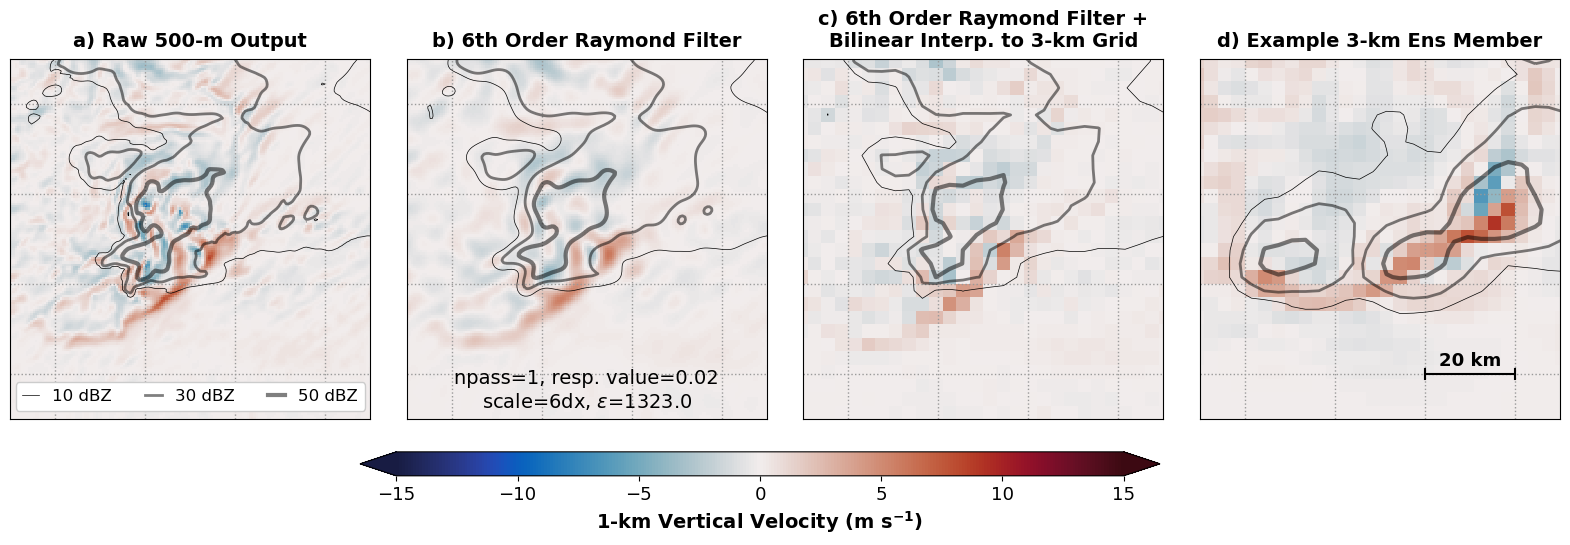

In [12]:
def add_scale(ax, xstart=200, xlength=50, y=280, cap_length=200*.04, text_bump =0):

    xend = xstart+xlength
    
    ax.plot([xstart,xend], [y,y], color='k')
    ax.plot([xstart,xstart], [y-cap_length/2,y+cap_length/2], color='k')
    ax.plot([xend, xend], [y-cap_length/2,y+cap_length/2], color='k', zorder=300)
    #ax.text(xstart+xlength/2, y-cap_length/2, '{xlength} km', ha='center', va='top', fontsize=13)
    ax.text(xstart+xlength/2, text_bump+y+cap_length/2, f'{xlength} km', ha='center', va='bottom', fontsize=13, weight='bold')


def plot_dbz(ax,x,y, dbz):

    ax.contour(x,y,dbz,  levels=[10], colors='k', linewidths=0.5)
    ax.contour(x,y,dbz,  levels=[30], colors='k', linewidths=2, alpha=0.5)
    ax.contour(x,y,dbz,  levels=[50], colors='k', linewidths=3, alpha=0.5)

    
fig, axes = plt.subplots(1,4, figsize=(20,6), sharex=True, sharey=True, subplot_kw={'aspect':'equal'})

ref_levs = [10, 30, 50]

for ax, var, var2 in zip(axes, [w, filtered_w], [dbz, filtered_dbz]):

    im=ax.pcolormesh(x,y,var,  vmin=-15, vmax=15,cmap=cmaps.balance)
    #ax.contour(x,y,var2,  levels=ref_levs, colors='k', linewidths=1)
    plot_dbz(ax, x, y, var2)

    # ax.set_xlim(220,300)
    # ax.set_ylim(90,160)]

    ax.set_xticks(np.arange(110,300,20))
    ax.set_yticks(np.arange(10,300,20))

    ax.set_xlim(200,280)
    ax.set_ylim(60,140)

    # ax.set_xlim(190-100,250+100)
    # ax.set_ylim(160-100,220+100)

axes[2].pcolormesh(xg,yg,filtered_regridded_w,  vmin=-15, vmax=15,cmap=cmaps.balance)

plot_dbz(axes[2], xg,yg,filtered_regridded_dbz)
axes[3].pcolormesh(xg,yg,ens_w,  vmin=-10, vmax=10,cmap=cmaps.balance)
plot_dbz(axes[3], xg,yg,ens_dbz)




plt.subplots_adjust(wspace=0.1)   

axes[0].set_title(f'a) Raw 500-m Output', fontsize=14, weight='bold', y=1.01)
axes[1].set_title(f'b) 6th Order Raymond Filter', fontsize=14, weight='bold', y=1.01);
axes[2].set_title(f'c) 6th Order Raymond Filter +\nBilinear Interp. to 3-km Grid', fontsize=14, weight='bold', y=1.01);
axes[3].set_title(f'd) Example 3-km Ens Member', fontsize=14, weight='bold', y=1.01)

txt = r'$\epsilon$'
#axes[1].text(210-8, 70-8, f'npass={npass}, resp. value={response_amp}\nscale={dx}dx, {txt}={eps:.1f}', fontsize=14)
axes[1].text(0.5, 0.02, f'npass={npass}, resp. value={response_amp}\nscale={dx}dx, {txt}={eps:.1f}', fontsize=14, ha='center', va='bottom', transform=axes[1].transAxes)

add_scale(axes[3], xstart=250, xlength=20, y= 70, cap_length=2)


for ax in axes:
    ax.tick_params(axis='both',  which='both', length=0,labelbottom=False,labelleft=False)
    ax.grid()



l10 = mpl.lines.Line2D([0], [0], label='10 dBZ', color='k',  linewidth=0.5)
l30 = mpl.lines.Line2D([0], [0], label='30 dBZ', color='k',  linewidth=2, alpha=0.5)
l50 = mpl.lines.Line2D([0], [0], label='50 dBZ', color='k',  linewidth=3, alpha=0.5)
axes[0].legend(handles=[l10,l30,l50], labels=['10 dBZ', '30 dBZ', '50 dBZ'], ncols=3, loc='lower center', handlelength=1, fontsize=12)

#cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.6])
cbar_ax = fig.add_axes([0.3, 0.1, .4, 0.04])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', extend='both')
cbar.set_label(r"1-km Vertical Velocity (m s$\mathbf{{^{-1}}}$) ", weight='bold')
plt.show()


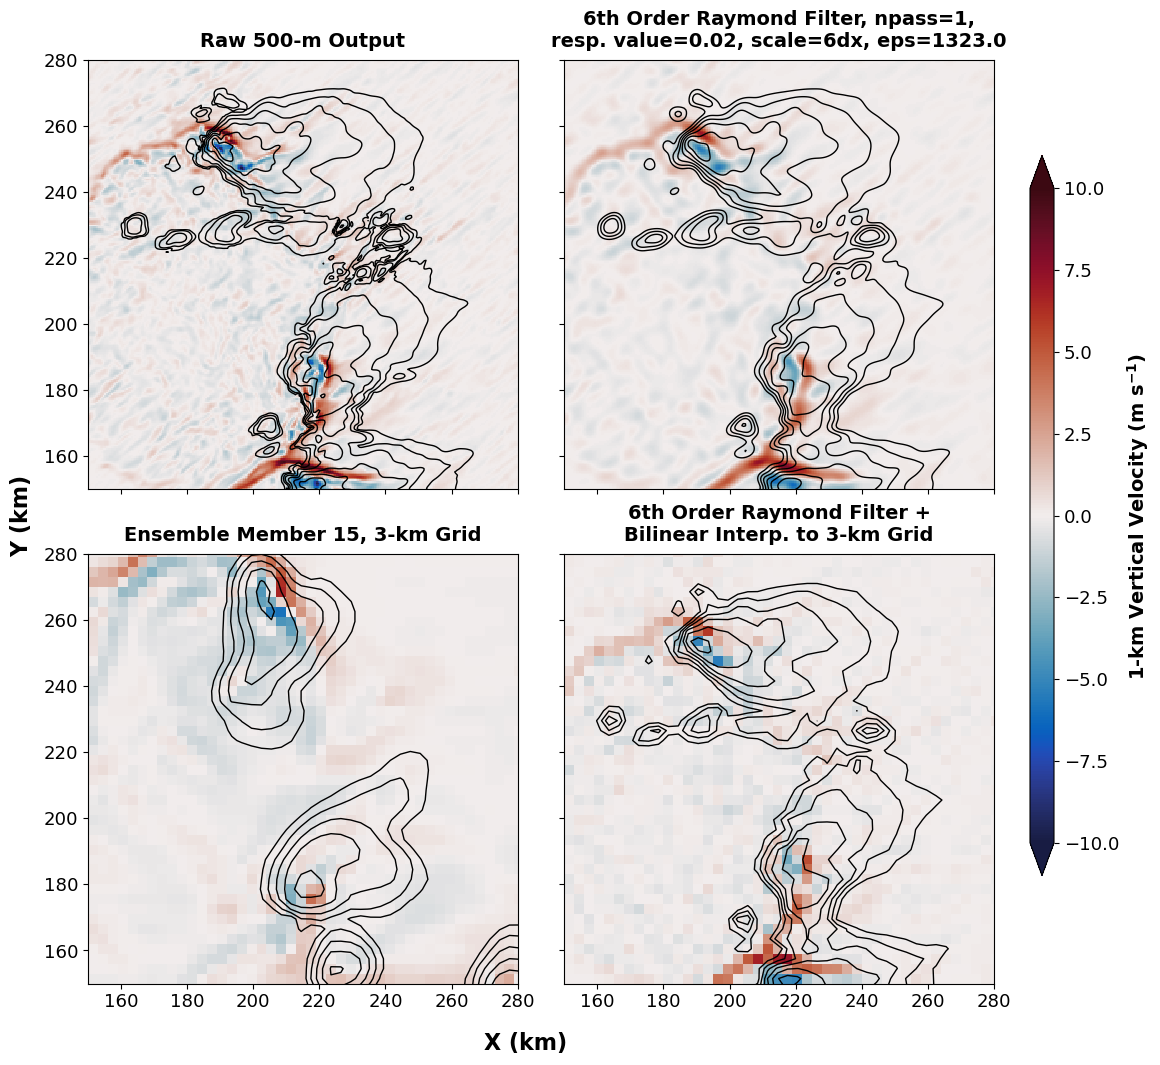

In [6]:
fig, axes = plt.subplots(2,2, figsize=(12,12), sharex=True, sharey=True, subplot_kw={'aspect':'equal'})

levels=[10,20,30,40,50,60]

for ax, var, var2 in zip(axes[0,:], [w, filtered_w], [dbz, filtered_dbz]):

    im=ax.pcolormesh(x,y,var,  vmin=-10, vmax=10,cmap=cmaps.balance)
    ax.contour(x,y,var2,  levels=levels, colors='k', linewidths=1)

    ax.set_xlim(150,250+30)
    ax.set_ylim(150,280)

axes[1,1].pcolormesh(xg,yg,filtered_regridded_w,  vmin=-10, vmax=10,cmap=cmaps.balance)
axes[1,1].contour(xg,yg,filtered_regridded_dbz,  levels=levels, colors='k', linewidths=1)

axes[1,0].pcolormesh(xg,yg,ens_w,  vmin=-10, vmax=10,cmap=cmaps.balance)
axes[1,0].contour(xg,yg,ens_dbz,  levels=levels, colors='k', linewidths=1)

plt.subplots_adjust(wspace=0.1)   

axes[0,0].set_title(f'Raw 500-m Output', fontsize=14, weight='bold', y=1.01)
axes[0,1].set_title(f'6th Order Raymond Filter, npass={npass},\nresp. value={response_amp}, scale={dx}dx, eps={eps:.1f}', fontsize=14, weight='bold', y=1.01);
axes[1,1].set_title(f'6th Order Raymond Filter +\nBilinear Interp. to 3-km Grid', fontsize=14, weight='bold', y=1.01);
axes[1,0].set_title(f'Ensemble Member 15, 3-km Grid', fontsize=14, weight='bold', y=1.01);

cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
cbar = fig.colorbar(im, cax=cbar_ax, extend='both')
cbar.set_label(r"1-km Vertical Velocity (m s$\mathbf{{^{-1}}}$) ", weight='bold')

plt.subplots_adjust(hspace=0.15, wspace=0.05)

fig.text(0.5, 0.06, 'X (km)', ha='center', va='center', weight='bold', fontsize=16);
fig.text(0.07,0.5, r'Y (km)', weight='bold', va='center', fontsize=16, rotation='vertical');

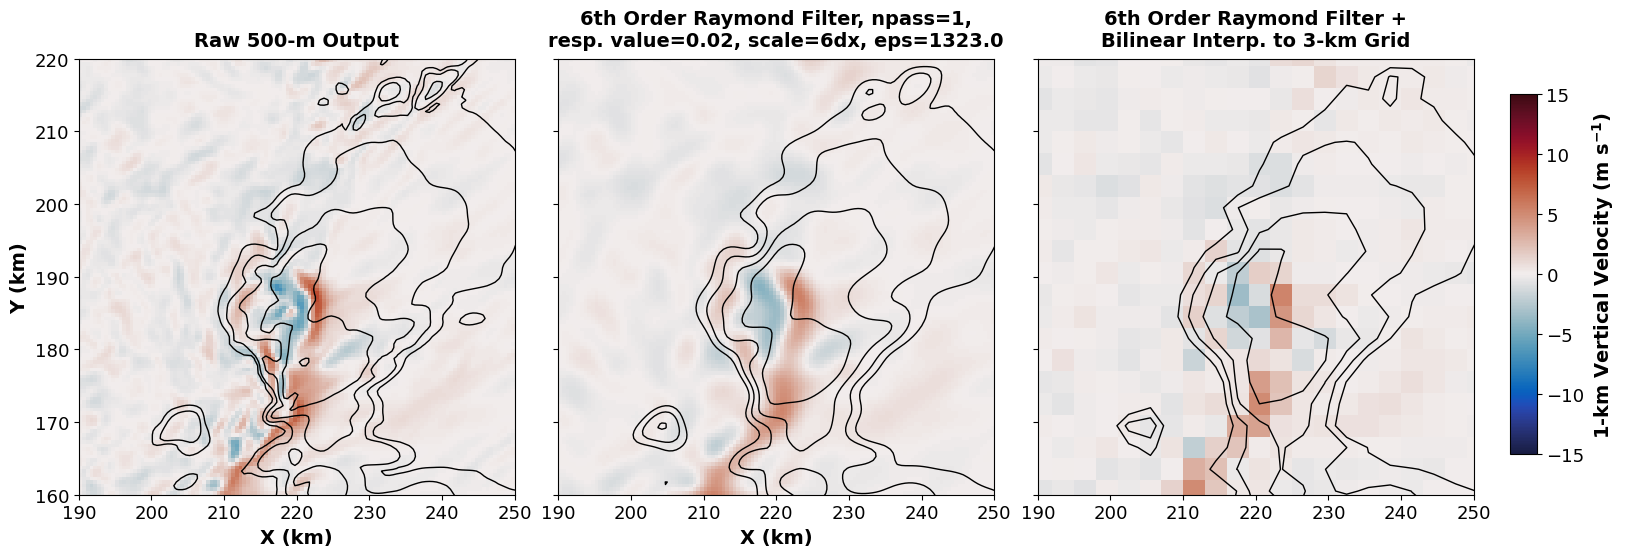

In [7]:
fig, axes = plt.subplots(1,3, figsize=(18,6), sharex=True, sharey=True, subplot_kw={'aspect':'equal'})

for ax, var, var2 in zip(axes, [w, filtered_w], [dbz, filtered_dbz]):

    im=ax.pcolormesh(x,y,var,  vmin=-15, vmax=15,cmap=cmaps.balance)
    ax.contour(x,y,var2,  levels=[20,30,40,50,60], colors='k', linewidths=1)

    ax.set_xlim(190,250)
    ax.set_ylim(160,220)

axes[2].pcolormesh(xg,yg,filtered_regridded_w,  vmin=-15, vmax=15,cmap=cmaps.balance)
axes[2].contour(xg,yg,filtered_regridded_dbz,  levels=[20,30,40,50,60], colors='k', linewidths=1)

plt.subplots_adjust(wspace=0.1)   

axes[0].set_title(f'Raw 500-m Output', fontsize=14, weight='bold', y=1.01)
axes[1].set_title(f'6th Order Raymond Filter, npass={npass},\nresp. value={response_amp}, scale={dx}dx, eps={eps:.1f}', fontsize=14, weight='bold', y=1.01);
axes[2].set_title(f'6th Order Raymond Filter +\nBilinear Interp. to 3-km Grid', fontsize=14, weight='bold', y=1.01);

axes[0].set_ylabel('Y (km)', weight='bold')
axes[0].set_xlabel('X (km)', weight='bold')
axes[1].set_xlabel('X (km)', weight='bold')

cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.6])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label(r"1-km Vertical Velocity (m s$\mathbf{{^{-1}}}$) ", weight='bold')

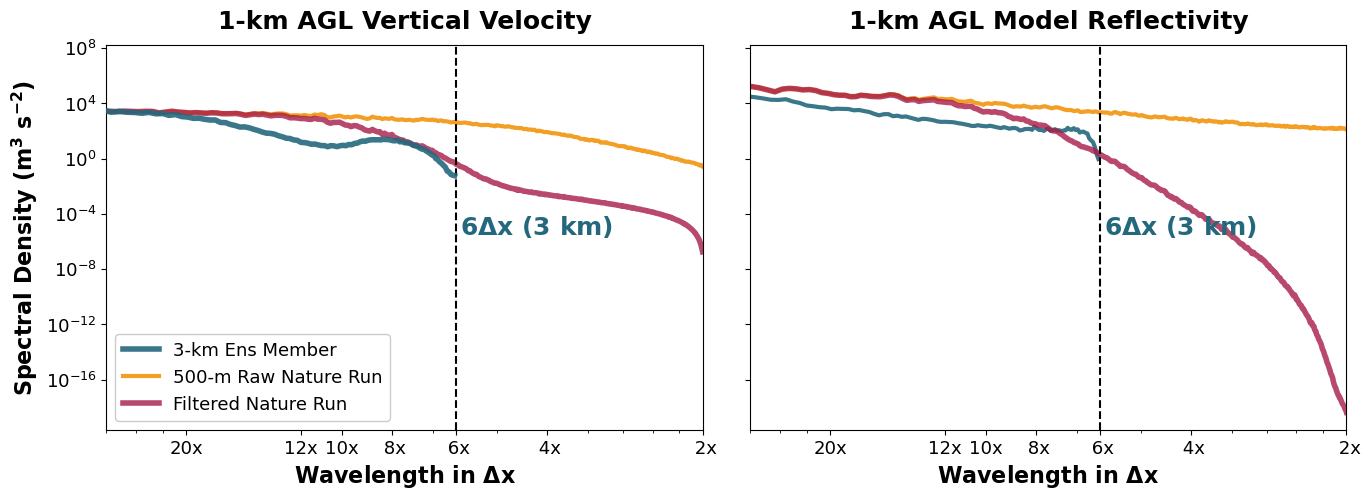

In [13]:
def quick_plot(ax, var,stop=None, **kwargs):
    kvals, Abins, waven = get_spectra2D_DCT(var)

    if stop != None:
        x = findnearest(waven, 2.0/stop)
        ax.loglog(waven[:x], Abins[:x], **kwargs )
    else:
        ax.loglog(waven, Abins, **kwargs )


fig, axes = plt.subplots(1,2, sharex=True, sharey=True, figsize=(16, 5), facecolor='none')
colors=colors = cmaps.pride([.2, .6, .8])

quick_plot(axes[0],temp[6:-6, 6:-6],stop=6, color=colors[0], lw=4, alpha=0.9, label='3-km Ens Member', zorder=50)#label='Interpolated 3-km Ens Member')

quick_plot(axes[0],w, color=colors[1], lw=3, alpha=0.9, label= '500-m Raw Nature Run')
quick_plot(axes[0],filtered_w, color=colors[2], lw=4, alpha=0.8, label='Filtered Nature Run')


quick_plot(axes[1],tempdbz[6:-6, 6:-6],stop=6, color=colors[0], lw=3, alpha=0.9, label='Interpolated 3-km Ens Member')

quick_plot(axes[1],dbz, color=colors[1], lw=3, alpha=0.9, label= '500-m Raw Nature Run')
quick_plot(axes[1],filtered_dbz, color=colors[2], lw=4, alpha=0.8,  label='Filtered Nature Run')


axes[0].set_xlim(3.5/50, 1.0)
axes[0].xaxis.set_major_formatter(lambda x, pos: str(int(2.0/x)))
axes[0].legend(fontsize=13, loc=3)

axes[0].set_ylabel(r"Spectral Density (m$\mathbf{^3}$ s$\mathbf{^{-2}}$)", fontsize=16)


for ax in axes:
    
    ax.set_xlabel(r"Wavelength in $\mathbf{\Delta}$x", fontsize=16)

    for n in [6]:
        ax.axvline(2.0/n, color='k', ls='--')
        ax.annotate(str(n)+r"$\mathbf{\Delta}$x (3 km)", xy=(2.0/n+.005, ax.get_ylim()[0]+.000003), xycoords='data',fontsize=18, color=colors[0], weight='bold')

plt.subplots_adjust(wspace=0.08)

for ax in axes:

    # Label x-axis
    xlabels    = [f"{x:2d}x" for x in [2, 4, 6, 8, 10, 12, 20]]
    label_xlim = [2.0/x for x in [2, 4, 6, 8, 10, 12, 20]]
    ax.set_xticks(label_xlim, xlabels)
    # for n, n in enumerate([2.0, 4.0, 6.0, 8.0, 10., 12.]):
    #     ax.axvline(x = 2.0/n, color = "grey", alpha=0.5, label = "axvline - full height")
    

axes[0].set_title('1-km AGL Vertical Velocity', weight='bold', y=1.02);
axes[1].set_title('1-km AGL Model Reflectivity', weight='bold', y=1.02);

NameError: name 'regridded_w' is not defined

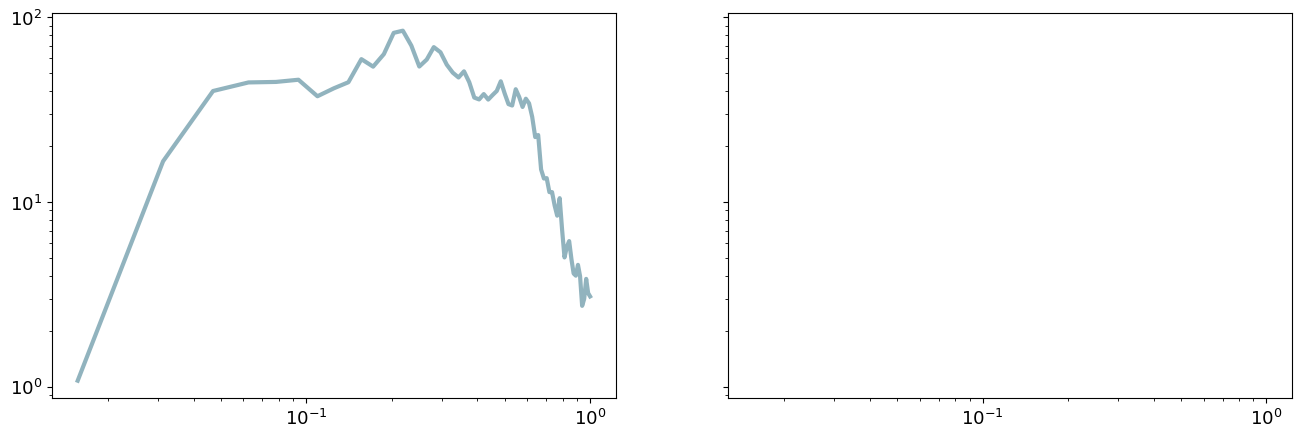

In [10]:
def quick_plot(ax, var,stop=None, **kwargs):
    kvals, Abins, waven = get_spectra2D_DCT(var)

    if stop != None:
        x = findnearest(waven, 2.0/stop)
        ax.loglog(waven[:x], Abins[:x], **kwargs )
    else:
        ax.loglog(waven, Abins, **kwargs )



## idk where the regridded only code went... fuck my life

colors=colors = cmaps.pride(np.linspace(.2, .8, 2))

fig, axes = plt.subplots(1,2, sharex=True, sharey=True, figsize=(16, 5))


quick_plot(axes[0],ens_w,color=colors[0], lw=3, alpha=0.5, label='3-km Ens Member')

quick_plot(axes[0],regridded_w, color='k', lw=3, alpha=0.3, label= 'Interpolated Nature Run')
quick_plot(axes[0],filtered_regridded_w, color=colors[1], lw=3, alpha=0.5, label='Filtered and Interpolated Nature Run')


quick_plot(axes[1],ens_dbz, color=colors[0], lw=3, alpha=0.5, label='3-km Ens Member')

quick_plot(axes[1],regridded_dbz, color='k', lw=3, alpha=0.3, label= '500-m Raw Nature Run')
quick_plot(axes[1],filtered_regridded_dbz, color=colors[1], lw=3, alpha=0.5, label='Filtered and Regridded Nature Run')


axes[0].set_xlim(2/50, 1.0)
axes[0].xaxis.set_major_formatter(lambda x, pos: str(int(2.0/x)))
axes[0].legend(fontsize=13, loc=2)

axes[0].set_ylabel(r"Spectral Density (m$\mathbf{^3}$ s$\mathbf{^{-2}}$)", fontsize=16)


for ax in axes:
    
    ax.set_xlabel(r"Wavelength in ($\mathbf{\Delta}$x)", fontsize=16)

    # for n in [6]:
    #     ax.axvline(2.0/n, color='k', ls='--')
    #     ax.annotate(str(n)+r"$\mathbf{\Delta}$x", xy=(2.0/n+.005, ax.get_ylim()[0]+.000000001), xycoords='data',fontsize=15, color=colors[0], weight='bold')

plt.subplots_adjust(wspace=0.08)

axes[0].set_title('1-km AGL Vertical Velocity', weight='bold', y=1.02);
axes[1].set_title('1-km AGL Model Reflectivity', weight='bold', y=1.02);

# 1.5 km ensemble

In [13]:
ds = xr.open_dataset('/work/jessica.mcdonald/scratch_link/NatureRuns/extra_NR_500m_may8/Full_Verification_variables.nc')

zi = findnearest(ds.zh,1)
ti = 140

x,y,z = ds.xh.values, ds.yh.values, ds.zh
w = ds['wa'][ti,zi,:,:].values
dbz = ds['dbz'][ti,zi,:,:].values

print(ds.dates[ti].values)



dx_NR = 500
dx_filter = 1500 # this is the scale that everything smaller than will be filtered out
dx = int(dx_filter/dx_NR)
response_amp = 0.02
npass=1

eps = RaymondFilters.inverseRaymondResponse(response_amp, dx, npass=npass)

filtered_w = RaymondFilters.RaymondFilter6F(w.T, eps, npass=npass)
filtered_dbz = RaymondFilters.RaymondFilter6F(dbz.T, eps, npass=npass)


# now also create filtered and regridded dataset, if it doesn't already exist 

2024-05-08T22:00:00.000000000
NPass Loop for 2D array took 0.0286 seconds

NPass Loop for 2D array took 0.0284 seconds



In [14]:
mem = 30
ens = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H09_V2_fine/member{mem:03d}/cm1rst_000038.nc', decode_timedelta=False) #15 19 31
ens_w = ens.wa[0, findnearest(ens.zf, 1000),:,:].values

ens_dbz = ens.dbz[0, findnearest(ens.zf, 1000),:,:].values
print(dt.datetime(2024,5,8,19,30) + dt.timedelta(minutes =int(ens.time.values[0]/60 )))


xg,yg,zg = ens.xh.values, ens.yh.values,ens.zh.values

# these come from the verfication dataset
xi,yi = np.meshgrid(x, y)

finterp = scipy.interpolate.RegularGridInterpolator((ens.yh.values/1000, ens.xh.values/1000), ens_w, bounds_error=False) #give it the filtered 500 m data
temp = np.transpose(finterp((yi.flatten(),xi.flatten())).reshape((len(y), len(x)), order='F'))#, axes=[0,2,1])

dinterp = scipy.interpolate.RegularGridInterpolator((ens.yh.values/1000, ens.xh.values/1000), ens_dbz, bounds_error=False) #give it the filtered 500 m data
tempdbz = np.transpose(dinterp((yi.flatten(),xi.flatten())).reshape((len(y), len(x)), order='F'))#, axes=[0,2,1])

2024-05-08 22:00:00


In [15]:
xe,ye = np.meshgrid( xg, yg)
    
finterp = scipy.interpolate.RegularGridInterpolator((y*1000,x*1000), w, bounds_error=False) #give it the filtered 500 m data
filtered_regridded_w = np.transpose(finterp((ye.flatten(),xe.flatten())).reshape((len(yg), len(xg)), order='F'))

interp = scipy.interpolate.RegularGridInterpolator((y*1000,x*1000), dbz, bounds_error=False) #give it the filtered 500 m data
filtered_regridded_dbz = np.transpose(interp((ye.flatten(),xe.flatten())).reshape((len(yg), len(xg)), order='F'))

In [12]:
# dx_NR = 500
# dx_filter = 1500 # this is the scale that everything smaller than will be filtered out
# dx = int(dx_filter/dx_NR)
# response_amp = .02
# npass=1

eps = RaymondFilters.inverseRaymondResponse(response_amp, dx, npass=npass)

filtered_w = RaymondFilters.RaymondFilter6F(w.T, eps, npass=npass)
filtered_dbz = RaymondFilters.RaymondFilter6F(dbz.T, eps, npass=npass)


NPass Loop for 2D array took 0.0284 seconds

NPass Loop for 2D array took 0.0285 seconds



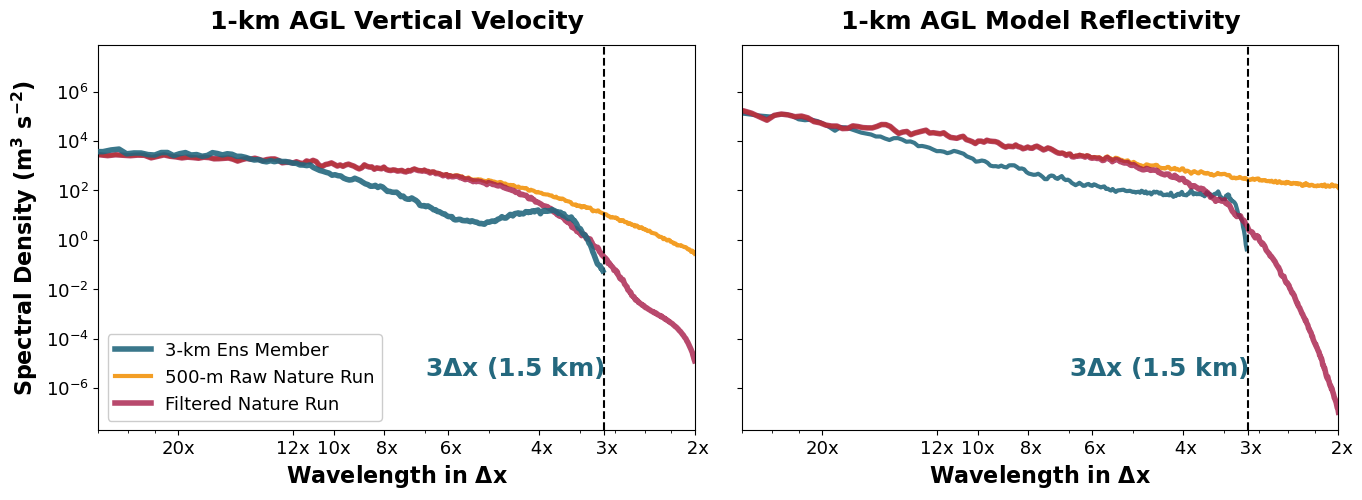

In [6]:
def quick_plot(ax, var,stop=None, **kwargs):
    kvals, Abins, waven = get_spectra2D_DCT(var)

    if stop != None:
        x = findnearest(waven, 2.0/stop)
        ax.loglog(waven[:x], Abins[:x], **kwargs )
    else:
        ax.loglog(waven, Abins, **kwargs )


fig, axes = plt.subplots(1,2, sharex=True, sharey=True, figsize=(16, 5), facecolor='none')
colors=colors = cmaps.pride([.2, .6, .8])

quick_plot(axes[0],temp[6:-6, 6:-6],stop=3, color=colors[0], lw=4, alpha=0.9, label='3-km Ens Member', zorder=50)#label='Interpolated 3-km Ens Member')

quick_plot(axes[0],w, color=colors[1], lw=3, alpha=0.9, label= '500-m Raw Nature Run')
quick_plot(axes[0],filtered_w, color=colors[2], lw=4, alpha=0.8, label='Filtered Nature Run')


quick_plot(axes[1],tempdbz[6:-6, 6:-6],stop=3, color=colors[0], lw=3, alpha=0.9, label='Interpolated 3-km Ens Member')

quick_plot(axes[1],dbz, color=colors[1], lw=3, alpha=0.9, label= '500-m Raw Nature Run')
quick_plot(axes[1],filtered_dbz, color=colors[2], lw=4, alpha=0.8,  label='Filtered Nature Run')


axes[0].set_xlim(3.5/50, 1.0)
axes[0].xaxis.set_major_formatter(lambda x, pos: str(int(2.0/x)))
axes[0].legend(fontsize=13, loc=3)

axes[0].set_ylabel(r"Spectral Density (m$\mathbf{^3}$ s$\mathbf{^{-2}}$)", fontsize=16)


for ax in axes:
    
    ax.set_xlabel(r"Wavelength in $\mathbf{\Delta}$x", fontsize=16)

    for n in [3]:
        ax.axvline(2.0/n, color='k', ls='--')
        ax.annotate(str(n)+r"$\mathbf{\Delta}$x (1.5 km)", xy=(2.0/n+.005, ax.get_ylim()[0]+.000003), xycoords='data',fontsize=18, ha='right',color=colors[0], weight='bold')

plt.subplots_adjust(wspace=0.08)

for ax in axes:

    # Label x-axis
    xlabels    = [f"{x:2d}x" for x in [2,3, 4, 6, 8, 10, 12, 20]]
    label_xlim = [2.0/x for x in [2, 3, 4, 6, 8, 10, 12, 20]]
    ax.set_xticks(label_xlim, xlabels)
    # for n, n in enumerate([2.0, 4.0, 6.0, 8.0, 10., 12.]):
    #     ax.axvline(x = 2.0/n, color = "grey", alpha=0.5, label = "axvline - full height")
    

axes[0].set_title('1-km AGL Vertical Velocity', weight='bold', y=1.02);
axes[1].set_title('1-km AGL Model Reflectivity', weight='bold', y=1.02);

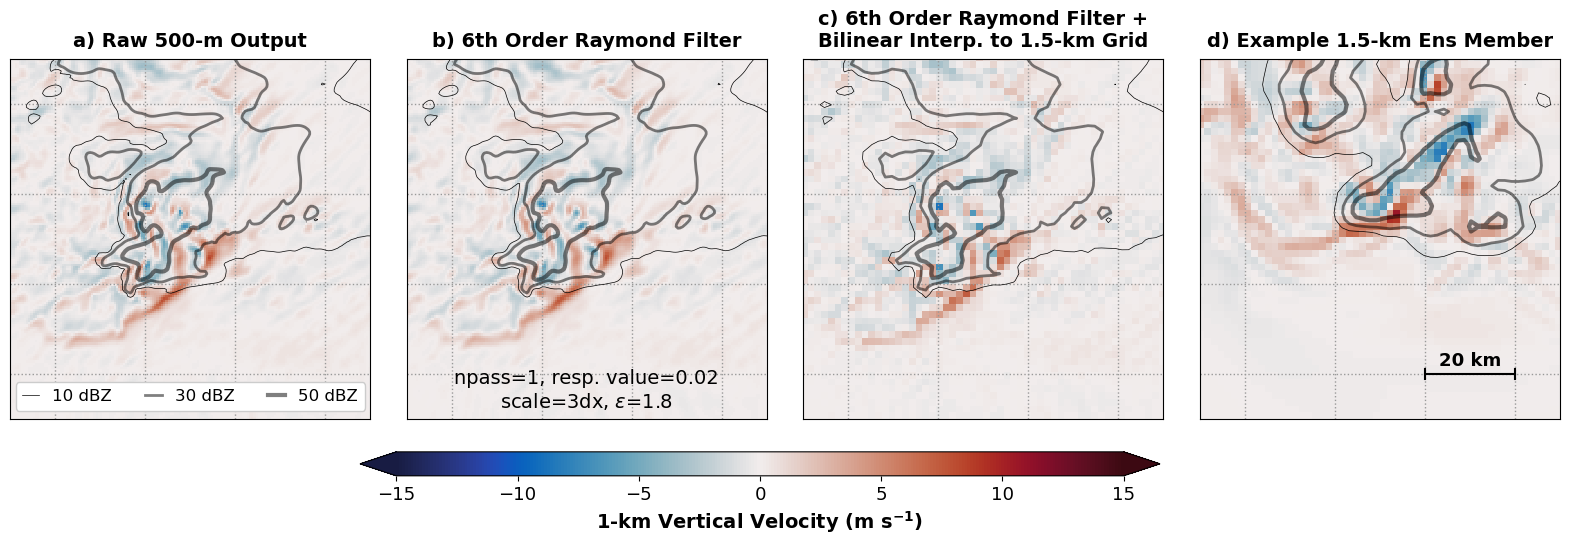

In [16]:
def add_scale(ax, xstart=200, xlength=50, y=280, cap_length=200*.04, text_bump =0):

    xend = xstart+xlength
    
    ax.plot([xstart,xend], [y,y], color='k')
    ax.plot([xstart,xstart], [y-cap_length/2,y+cap_length/2], color='k')
    ax.plot([xend, xend], [y-cap_length/2,y+cap_length/2], color='k', zorder=300)
    #ax.text(xstart+xlength/2, y-cap_length/2, '{xlength} km', ha='center', va='top', fontsize=13)
    ax.text(xstart+xlength/2, text_bump+y+cap_length/2, f'{xlength} km', ha='center', va='bottom', fontsize=13, weight='bold')


def plot_dbz(ax,x,y, dbz):

    ax.contour(x,y,dbz,  levels=[10], colors='k', linewidths=0.5)
    ax.contour(x,y,dbz,  levels=[30], colors='k', linewidths=2, alpha=0.5)
    ax.contour(x,y,dbz,  levels=[50], colors='k', linewidths=3, alpha=0.5)

    

xg,yg = ens.xh.values/1000, ens.yh.values/1000


fig, axes = plt.subplots(1,4, figsize=(20,6), sharex=True, sharey=True, subplot_kw={'aspect':'equal'})

ref_levs = [10, 30, 50]

for ax, var, var2 in zip(axes, [w, filtered_w], [dbz, filtered_dbz]):

    im=ax.pcolormesh(x,y,var,  vmin=-15, vmax=15,cmap=cmaps.balance)
    #ax.contour(x,y,var2,  levels=ref_levs, colors='k', linewidths=1)
    plot_dbz(ax, x, y, var2)

    # ax.set_xlim(220,300)
    # ax.set_ylim(90,160)]

    ax.set_xticks(np.arange(110,300,20))
    ax.set_yticks(np.arange(10,300,20))

    ax.set_xlim(200,280)
    ax.set_ylim(60,140)

    # ax.set_xlim(190-100,250+100)
    # ax.set_ylim(160-100,220+100)

axes[2].pcolormesh(xg,yg,filtered_regridded_w,  vmin=-15, vmax=15,cmap=cmaps.balance)

plot_dbz(axes[2], xg,yg,filtered_regridded_dbz)
axes[3].pcolormesh(xg,yg,ens_w,  vmin=-10, vmax=10,cmap=cmaps.balance)
plot_dbz(axes[3], xg,yg,ens_dbz)




plt.subplots_adjust(wspace=0.1)   

axes[0].set_title(f'a) Raw 500-m Output', fontsize=14, weight='bold', y=1.01)
axes[1].set_title(f'b) 6th Order Raymond Filter', fontsize=14, weight='bold', y=1.01);
axes[2].set_title(f'c) 6th Order Raymond Filter +\nBilinear Interp. to 1.5-km Grid', fontsize=14, weight='bold', y=1.01);
axes[3].set_title(f'd) Example 1.5-km Ens Member', fontsize=14, weight='bold', y=1.01)

txt = r'$\epsilon$'
#axes[1].text(210-8, 70-8, f'npass={npass}, resp. value={response_amp}\nscale={dx}dx, {txt}={eps:.1f}', fontsize=14)
axes[1].text(0.5, 0.02, f'npass={npass}, resp. value={response_amp}\nscale={dx}dx, {txt}={eps:.1f}', fontsize=14, ha='center', va='bottom', transform=axes[1].transAxes)

add_scale(axes[3], xstart=250, xlength=20, y= 70, cap_length=2)


for ax in axes:
    ax.tick_params(axis='both',  which='both', length=0,labelbottom=False,labelleft=False)
    ax.grid()



l10 = mpl.lines.Line2D([0], [0], label='10 dBZ', color='k',  linewidth=0.5)
l30 = mpl.lines.Line2D([0], [0], label='30 dBZ', color='k',  linewidth=2, alpha=0.5)
l50 = mpl.lines.Line2D([0], [0], label='50 dBZ', color='k',  linewidth=3, alpha=0.5)
axes[0].legend(handles=[l10,l30,l50], labels=['10 dBZ', '30 dBZ', '50 dBZ'], ncols=3, loc='lower center', handlelength=1, fontsize=12)

#cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.6])
cbar_ax = fig.add_axes([0.3, 0.1, .4, 0.04])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', extend='both')
cbar.set_label(r"1-km Vertical Velocity (m s$\mathbf{{^{-1}}}$) ", weight='bold')
plt.show()


AttributeError: 'Dataset' object has no attribute 'winterp'

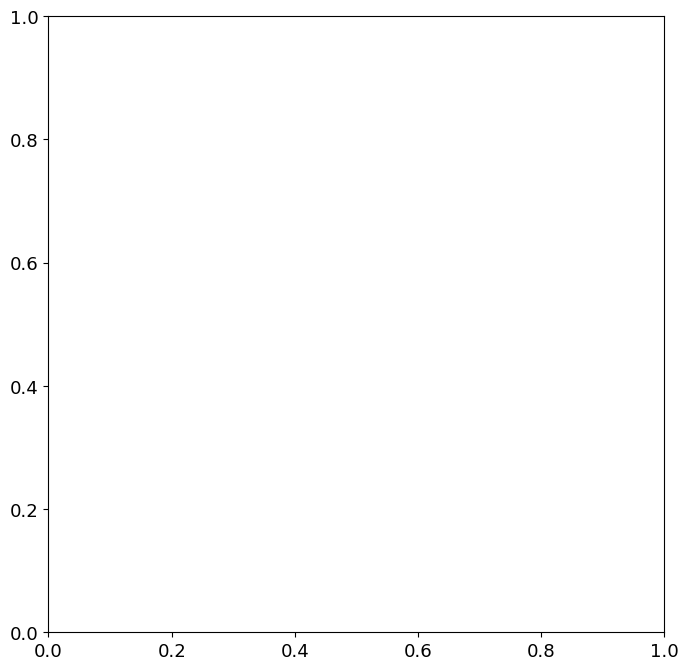

In [60]:
mem = 6
ens = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H09_V2_fine/member{mem:03d}/cm1rst_000038.nc', decode_timedelta=False) #15 19 31

ens_sub = ens.isel(ni=slice(findnearest(ens.xh, 200000), findnearest(ens.xh, 280000)), nj=slice(findnearest(ens.yh, 60000), findnearest(ens.yh, 140000)), nk=findnearest(ens.zh, 1000))

fig = plt.figure(figsize=(8,8))
ax = plt.gca()
ax.set_aspect('equal')


im=ax.pcolormesh(x,y, ens_sub.winterp.values[0,:,:],  vmin=-15, vmax=15,cmap=cmaps.balance)

plot_dbz(ax, ens_sub.xh/1000, ens_sub.yh/1000, ens_sub.dbz.values[0,:,:])




In [55]:
ens_sub

<xarray.Dataset> Size: 2MB
Dimensions:       (time: 1, ni: 53, nip1: 257, nj: 54, njp1: 257, nkp1: 53,
                   nbudget: 10, numq: 16)
Coordinates:
  * time          (time) float32 4B 9e+03
Dimensions without coordinates: ni, nip1, nj, njp1, nkp1, nbudget, numq
Data variables: (12/124)
    xh            (ni) float32 212B 2.002e+05 2.018e+05 ... 2.768e+05 2.782e+05
    xf            (nip1) float32 1kB ...
    yh            (nj) float32 216B 5.925e+04 6.075e+04 ... 1.372e+05 1.388e+05
    yf            (njp1) float32 1kB ...
    zh            float32 4B 1.007e+03
    zf            (nkp1) float32 212B ...
    ...            ...
    radbcs        (time, ni) float32 212B ...
    radbcn        (time, ni) float32 212B ...
    theta         (time, nj, ni) float32 11kB ...
    dbz           (time, nj, ni) float32 11kB ...
    pi0           (time, nj, ni) float32 11kB ...
    rho0          (time, nj, ni) float32 11kB ...
Attributes: (12/62)
    nx:          256
    ny:          256
    nz:          52
    imoist:      1
    sgsmodel:    1
    tconfig:     1
    ...          ...
    cgt1:        1.875
    cgt2:        -1.25
    cgt3:        0.375
    dgt1:        2.0
    dgt2:        -3.0
    dgt3:        1.0